# Homework: Learning Audio Representations with Self-Supervision

In this homework, we will consolidate the knowledge gained during the seminar and further explore methods for self-supervised learning of audio representations.
During the seminar, we implemented and trained a model based on contrastive learning (InfoNCE). Now, we will extend this work by implementing non-contrastive learning (NCL) approaches and comparing them with previously studied methods.

We will examine how different training paradigms — supervised, contrastive, and non-contrastive — affect the quality of learned embeddings and the stability of the training process


## Multi-Format Contrastive Learning of Audio Representations(Paper from seminar)

The core idea of this approach is to learn robust audio embeddings by contrasting
different *formats* (or views) of the same audio sample.  
For example, one branch may encode the **raw waveform (1D)** while another encodes
its **spectrogram (2D)**.  

By applying a contrastive loss (InfoNCE), the model is trained to:
- **Pull together** embeddings from different formats of the same audio,
- **Push apart** embeddings from different audio samples.  

This multi-format setup encourages the encoder to capture **shared semantic content**
across input representations, leading to more general and transferable audio features.

[paper1](https://arxiv.org/pdf/2103.06508), [paper2](https://arxiv.org/pdf/2010.09542)

[github source](https://github.com/HondamunigePrasannaSilva/CLAR?tab=readme-ov-file)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import random
import numpy as np
from pathlib import Path
from IPython.display import clear_output
import torchaudio.transforms as T
from torch.nn.utils.rnn import pad_sequence
import copy
import time
import itertools

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

## AudioSet

Dataset with 10 numbers pronounced
```
!git clone https://github.com/soerenab/AudioMNIST.git
```



In [ ]:
class AudioMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000, device=None):
        """
        Dataset для AudioMNIST, возвращает тройку (wav, spec, label)
        
        Args:
            root : путь к датасету
            sr : частота дискретизации
            device : torch.device, куда сразу помещать тензоры
        """
        self.root = root
        self.sr = sr
        self.device = device or torch.device('cpu')
        self.items = self.list_wavs_and_labels(root)
        # создаём mel один раз и используем для всех wav
        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sr,
            n_mels=64,
            n_fft=400,
            hop_length=160,
            center=False
        )

    def __len__(self):
        return len(self.items)

    def list_wavs_and_labels(self, root: str):
        base = Path(root)
        speakers = sorted([p for p in base.iterdir() if p.is_dir()])
        items = []
        for sp in speakers:
            for wav_path in sorted(sp.glob("**/*.wav")):
                digit = int(wav_path.stem.split("_")[0])
                speaker_id = sp.name
                items.append((str(wav_path), digit, speaker_id))
        return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav
    '''
    def _wav_to_spec(self, wav):
        # wav на устройстве CPU
        spec = self.mel_transform(wav.cpu())  # mel всегда на CPU
        spec = torch.log(spec + 1e-6)
        return spec
    '''
    def wav_to_spec(self, wav, n_fft=400, hop_length=160, win_length=400):
        """
        wav: [1, T] или [T]
        return: [F, T']
        """
        if wav.ndim == 1:
            wav = wav.unsqueeze(0)  # -> [1, T]

        device = wav.device
        T = wav.size(1)

        # паддинг если слишком короткий сигнал
        if T < n_fft:
            wav = F.pad(wav, (0, n_fft - T))

        window = torch.hann_window(win_length, device=device)

        spec = torch.stft(
            wav,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            window=window,
            return_complex=True
        )

        spec = torch.abs(spec)  # [1, F, T']
        return spec.squeeze(0)  # -> [F, T']
    
    def __getitem__(self, idx):
        path, label, speaker = self.items[idx]
        wav = self.load_wav(path)         # [1, T]
        spec = self.wav_to_spec(wav)      # [F, T]
        label = torch.tensor(label, dtype=torch.long)
        return wav, spec, label

## Model from the seminar

#### Используем энкодер **ResNet2D**
- **Input:** `[batch, channels, height, width]`  
- **First layer:** `Conv2d(7x7, stride=2)` → BatchNorm → ReLU → MaxPool2d  
- **Residual blocks:** `[2, 2, 2, 2]` blocks with channels `[64, 128, 256, 512]`  
- **Each block:** `Conv2d(1x1)` + `Conv2d(3x3)` with skip connection  
- **Output:** Global average pooled feature `[batch, 512, 1, 1]`  

This encoder *slides filters along time and frequency dimensions* to capture **spectro-temporal patterns** in spectrograms.

In [3]:
class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block, self).__init__()

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x


class ResNet1D(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block):
        super(ResNet1D, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool1d(output_size=1)


        # size after avgpool = [32, 512, 1]

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        #x = x.reshape(x.shape[0], -1)
        #x = self.fc(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv1d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm1d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet1D():
    return ResNet1D(block)

class block_resnet2d(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None,stride=1):
        super(block_resnet2d, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.identity_downsample = identity_downsample
        self.relu = nn.ReLU()


    def forward(self, x):
        identity = x

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)

        x += identity
        x = self.relu(x)

        return x

class ResNet(nn.Module):
    # Resnet 18 [2, 2, 2, 2]
    def __init__(self, block, image_channels):
        super(ResNet, self).__init__()
        # for resnet18
        layers = [2, 2, 2, 2]
        self.expansion = 1

        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)


        self.layer1 = self._make_layer(block, layers[0], 64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], 128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], 256, stride=2)
        self.layer4 = self._make_layer(block, layers[3], 512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))


    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        return x



    def _make_layer(self, block, num_residual_block, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels,
                                                out_channels*self.expansion,
                                                kernel_size=1,
                                                stride=stride,
                                                bias=False),
                                                nn.BatchNorm2d(out_channels*self.expansion),
                                                )
        layers.append(
            block(self.in_channels,out_channels, identity_downsample, stride)
        )
        self.in_channels = out_channels * self.expansion

        for i in range(1, num_residual_block):
            layers.append(block(self.in_channels,out_channels ))

        return nn.Sequential(*layers)



def CreateResNet2D(img_channels=3):
    return ResNet(block_resnet2d, image_channels=img_channels)

In [4]:
class Net(nn.Module):

    def __init__(self, img_channels = 1, num_classes = 35):
        super(Net, self).__init__()
        ####################### ENCODER ###################################
        self.resnet_1D = CreateResNet1D()
        self.resnet_2D = CreateResNet2D(img_channels=img_channels)

        self.output = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128)
        )

        ####################################################################

    def forward(self, input_spectogram, input_audio):
        """
            resnet2d and resnet1d output is [BS, 512, 1, 1]
            Output:
                - audio_emb, specs_emb used for contrastive loss
                - audio, spectograms used for Evaluation layer
                - output used for semi supervised - cross entropy
        """

        audio = self.resnet_1D(input_audio)
        # audio = audio.squeeze() # опасно
        audio = audio.view(audio.size(0), -1)
        spectograms = self.resnet_2D(input_spectogram)
        # spectograms = spectograms.squeeze() # опасно
        spectograms = spectograms.view(spectograms.size(0), -1)

        audio_emb = self.output(audio)
        specs_emb = self.output(spectograms)

        return audio_emb, specs_emb, audio, spectograms

##  Подготовка данных (AudioMNIST)
Добавим спектрограмму + аугментации (в SSL аугментации критичнее модели: слабый augment убивает качество):

In [ ]:
'''
mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=64,
    n_fft=400,
    hop_length=160,
    center=False  
)

def wav_to_spec(wav):
    # wav на устройстве CPU
    spec = mel(wav.cpu())  # mel всегда на CPU
    spec = torch.log(spec + 1e-6)
    return spec.to(device)  # переносим на GPU после преобразования

def _wav_to_spec(wav, n_fft=400, hop_length=160, win_length=400):
    """
    wav: [1, T] или [T]
    return: [F, T']
    """
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)  # -> [1, T]

    device = wav.device
    T = wav.size(1)

    # паддинг если слишком короткий сигнал
    if T < n_fft:
        wav = F.pad(wav, (0, n_fft - T))

    window = torch.hann_window(win_length, device=device)

    spec = torch.stft(
        wav,
        n_fft=n_fft,
        hop_length=hop_length,
        win_length=win_length,
        window=window,
        return_complex=True
    )

    spec = torch.abs(spec)  # [1, F, T']
    return spec.squeeze(0)  # -> [F, T']
'''


# слабый вариант augment → это убивает качество.
'''
def augment(wav):
    noise = torch.randn_like(wav) * 0.01
    max_shift = max(1, wav.shape[-1] // 4)  # максимум 1/4 длины
    shift_val = torch.randint(0, max_shift, (1,)).item()
    shift = torch.roll(wav, shifts=shift_val, dims=-1)
    return wav + noise + shift
'''
def augment(wavs, sr=16000):
    """
    wavs: [B, 1, T]
    return: [B, 1, T]
    """
    augmented = []

    for wav in wavs:  # wav: [1, T]
        T = wav.shape[-1]

        # 1. Random crop
        crop_size = int(T * random.uniform(0.6, 1.0))
        start = random.randint(0, T - crop_size)
        w = wav[..., start:start+crop_size]

        # 2. Time stretch
        if random.random() < 0.5:
            rate = random.uniform(0.8, 1.2)
            w = torchaudio.functional.resample(w, sr, int(sr * rate))
            w = torchaudio.functional.resample(w, int(sr * rate), sr)

        # 3. Noise
        if random.random() < 0.5:
            w = w + torch.randn_like(w) * 0.01

        # 4. Gain
        if random.random() < 0.5:
            w = w * random.uniform(0.7, 1.3)

        # 5. Pad обратно
        if w.shape[-1] < T:
            w = F.pad(w, (0, T - w.shape[-1]))

        # 6. Crop если стало длиннее
        if w.shape[-1] > T:
            w = w[..., :T]

        augmented.append(w)

    return torch.stack(augmented)  # [B, 1, T]

`Замечание`: Cчитать кэш спектрограмм в каждом батче → медленно.

`Решение` (для маленьких датасетов, как AudioMNIST, когда хватает RAM):

In [6]:
class CachedAudioMNISTFlexible(torch.utils.data.Dataset):
    def __init__(self, root, sr=16000, mode='combined', device=None):
        """
        root : str - путь к датасету
        sr : int - частота дискретизации
        mode : str - режим аугментации: 'light', 'strong', 'combined'
        device : torch.device - устройство для выдачи батчей (cpu или cuda)
        """
        self.root = root
        self.sr = sr
        self.mode = mode
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.items = self.list_wavs_and_labels(root)
        self.cache = []

        # Кэшируем wav и спектрограммы на CPU
        for path, label, speaker in self.items:
            wav = self.load_wav(path)      # [1, T], cpu
            spec = wav_to_spec(wav)        # [freq, time], cpu
            self.cache.append((wav, spec, label))

    def list_wavs_and_labels(self, root: str):
        base = Path(root)
        speakers = sorted([p for p in base.iterdir() if p.is_dir()])
        items = []
        for sp in speakers:
            for wav_path in sorted(sp.glob("**/*.wav")):
                digit = int(wav_path.stem.split("_")[0])
                speaker_id = sp.name
                items.append((str(wav_path), digit, speaker_id))
        return items

    def load_wav(self, path):
        wav, sr = torchaudio.load(path)  # [C, T]
        if sr != self.sr:
            wav = torchaudio.functional.resample(wav, sr, self.sr)
        wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
        return wav

    def augment_wav(self, wav):
        # Здесь можно добавить сильные аугментации: шум, питч, скорость
        return augment(wav)

    def augment_spec(self, spec):
        # Лёгкая аугментация спектра: шум, сдвиг
        return spec + 0.01 * torch.randn_like(spec)

    def __getitem__(self, idx):
        wav, spec, label = self.cache[idx]
        wav, spec = wav.to(self.device), spec.to(self.device)

        if self.mode == 'strong':
            wav_aug = self.augment_wav(wav)
            spec_aug = wav_to_spec(wav_aug)
        elif self.mode == 'light':
            spec_aug = self.augment_spec(spec)
        elif self.mode == 'combined':
            wav_aug = self.augment_wav(wav)
            spec_aug = wav_to_spec(wav_aug)
            spec_aug = self.augment_spec(spec_aug)
        else:
            spec_aug = spec

        return wav, spec_aug, label

    def __len__(self):
        return len(self.cache)

    @staticmethod
    def collate_fn(batch):
        """
        Collate функция для спектрограмм с паддингом по временной оси.
        Возвращает:
            specs_padded : [B, freq, time_max]
            labels : [B]
        """
        wavs, specs, labels = zip(*batch)
    
        # паддим аудио
        wavs_padded = pad_sequence(wavs, batch_first=True)  # [B, T_max]
        wavs_padded = wavs_padded.unsqueeze(1)  # ✅ [B, 1, T]

        # паддим спектрограммы по времени
        specs = [s.T for s in specs]             # [T, F]
        specs_padded = pad_sequence(specs, batch_first=True)  # [B, T_max, F]
        specs_padded = specs_padded.permute(0, 2, 1)          # [B, F, T_max]

        labels_tensor = torch.tensor(labels, dtype=torch.long)
        return wavs_padded, specs_padded, labels_tensor

* спектрограммы кэшируются и аугментация не требует пересчета всего спектра, что ускоряет обучение.
* Не пересчитываем спектрограмму каждый раз после аугментации, что сильно ускоряет обучение.
* Лёгкая аугментация спектра (шум или сдвиг) сохраняет разнообразие данных.
* Кэшируем только то, что нужно для обучения, экономим память и время.
* В __init__ кэшируются только оригинальные спектрограммы.
* Аугментация применяется к wav на лету, но не пересчитываем спектрограмму заново, а используем лёгкие преобразования спектра (или заранее подготовленные методы).
* Храним кэш оригинальных wav и спектрограмм.
* Можно на лету применять сильную аугментацию к wav (например, скорость, питч, шум), и пересчитывать спектрограмму только при необходимости.
* Можно применять лёгкую аугментацию к уже кэшированной спектрограмме (шум, сдвиг), что быстро и экономно.
* Даём возможность выбирать режим аугментации: только лёгкая, только сильная, или комбинированная.
* Можно легко менять режим обучения, просто меняя mode.
* Кэширование wav + спектрограмм позволяет комбинировать аугментации без потери скорости.
* Лёгкая аугментация почти не влияет на производительность, сильная добавляет разнообразие.
* Батчи автоматически паддируются по временной оси.
* Поддержка CPU и GPU через аргумент device.
* Гибкий режим аугментации.
Это уменьшает накладные расходы при обучении.

In [7]:
def collate(batch):
        """
        - batch: список кортежей (wav, label)
        - wav: [1, T] тензор
        """
        # batch = список кортежей (wav, label)
        wavs, specs, labels = zip(*batch)

        # Проверяем размерность каждого wav и приводим к [1, T]
        processed_wavs = []
        for w in wavs:
            if w.ndim == 1:
                w = w.unsqueeze(0)  # [T] -> [1, T]
            elif w.ndim == 2 and w.size(0) != 1:
                w = w.mean(dim=0, keepdim=True)  # если >1 канал, делаем моно
            processed_wavs.append(w.squeeze(0))  # [1, T] -> [T] для pad_sequence

        # Паддинг до максимальной длины в батче
        wavs_padded = pad_sequence(processed_wavs, batch_first=True)  # [B, max_T]

        # Преобразуем labels в тензор
        labels_tensor = torch.tensor(labels, dtype=torch.long)

        # Для совместимости возвращаем три значения
        specs_padded = None

        return wavs_padded, specs_padded, labels_tensor

def collate_fn(batch):
    wavs, specs, labels = zip(*batch)

    # wav: [1, T] → [T]
    wavs = [w.squeeze(0) for w in wavs]

    # spec: [F, T] → [T, F]
    specs = [s.transpose(0, 1) for s in specs]

    # паддинг
    wavs = pad_sequence(wavs, batch_first=True)     # [B, T]
    specs = pad_sequence(specs, batch_first=True)   # [B, T, F]

    # обратно: [B, F, T]
    specs = specs.transpose(1, 2)

    labels = torch.stack(labels)

    return wavs, specs, labels

Такой Сollate работает отлично для wav, потому что все [1, T] приводятся к [T] и потом используется pad_sequence. 

Но может возникнуть ошибка именно для спектрограмм, потому что их размер [freq, time] и time может быть разным для каждого образца.

```wavs_padded = pad_sequence(processed_wavs, batch_first=True)  # [B, max_T]``` - работает только для 1D или 2D аудио, но не для `[freq, time]`. Поэтому нужно сделать аналог для спектрограмм, где паддинг будет по временной оси (`time`), а частота (`freq`) фиксирована.

Вот надёжная версия collate для спектрограмм:

In [8]:
def collate_specs(batch):
    """
    - batch: список кортежей (spec, label)
    - spec: [freq, time] тензор
    """
    # batch = список кортежей (spec, label)
    wavs, specs, labels = zip(*batch)
    
    # если есть исходные wav, можно их использовать, иначе создаём нулевой тензор с нужной длиной
    wavs_placeholder = [torch.zeros(s.shape[1]) for s in specs]  # [time] — длина равна time спектрограммы
    
    # паддим аудио (временные ряды)
    wavs_padded = pad_sequence(wavs_placeholder, batch_first=True)  # [B, T_max]
    wavs_padded = wavs_padded.unsqueeze(1)  # ✅ [B, 1, T]

    # паддим спектрограммы по времени
    specs_t = [s.T for s in specs]  # [T, F]
    specs_padded = pad_sequence(specs_t, batch_first=True)  # [B, T_max, F]
    specs_padded = specs_padded.permute(0, 2, 1)           # [B, F, T_max]

    labels_tensor = torch.tensor(labels, dtype=torch.long)

    return wavs_padded, specs_padded, labels_tensor

In [9]:
dataset = AudioMNISTDataset("content\\AudioMNIST")
#dataset = CachedAudioMNISTFlexible("content\\AudioMNIST", mode='combined') # требует отладки

loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=collate_fn, # dataset.collate_fn,
    #pin_memory=True,
    #num_workers=0, # для Windows + Jupiter только "0" из-за spawn
    #persistent_workers=True
)

`Замечание`: InfoNCE очень зависит от batch size - стоит попробовать: 64–128

## Графики обучения 📈 + Loger

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator # для целочисленных делений оси X
%matplotlib inline

def plot(train_accs_list, train_loss_list, epoch_times_list=None, 
         labels=["Supervised","InfoNCE","SimSiam","NCL","VICReg"]):
    
    n_subplots = 2 if epoch_times_list is None else 3
    plt.figure(figsize=(5 * n_subplots, 4))  # шире, ниже

    color_cycle = itertools.cycle(["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"])
    marker_cycle = itertools.cycle(["o", "s", "^", "D", "x"])

    # ===== Accuracy =====
    plt.subplot(1, n_subplots, 1)
    for acc, label in zip(train_accs_list, labels):
        plt.plot(acc, marker=next(marker_cycle), color=next(color_cycle), label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training Accuracy")
    plt.grid(True)
    plt.legend()
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # целочисленная ось X

    # ===== Loss =====
    plt.subplot(1, n_subplots, 2)
    for loss, label, color, marker in zip(train_loss_list, labels, color_cycle, marker_cycle):
        plt.plot(loss, marker=marker, color=color, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True)
    plt.legend()
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # целочисленная ось X

    # ===== Time =====
    if epoch_times_list is not None:
        plt.subplot(1, n_subplots, 3)
        for times, label, color, marker in zip(epoch_times_list, labels, color_cycle, marker_cycle):
            plt.plot(times, marker=marker, color=color, label=label)
        plt.xlabel("Epoch")
        plt.ylabel("Time (s)")
        plt.title("Epoch Time")
        plt.grid(True)
        plt.legend()
        plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))  # целочисленная ось X

    plt.tight_layout()
    plt.show()

In [11]:
class Loger:
    def __init__(self, model_name, n_epochs):
        self.model_name = model_name
        self.n_epochs = n_epochs

        # текущие значения метрик
        self.epoch_loss, self.epoch_acc = 0.0, 0.0
        self.elapsed = 0.0
        self.proxy_acc = 0.0
        self.lin_acc, self.lin_loss = 0.0, 0.0 

        # словарь метрик с геттерами и форматами
        self._fields = {
            "loss": {"getter": lambda: self.epoch_loss, "format": "{:.4f}"},
            "acc": {"getter": lambda: self.epoch_acc, "format": "{:.4f}"},
            "time": {"getter": lambda: self.elapsed, "format": "{:.2f}s"},
            "proxy_acc": {"getter": lambda: self.proxy_acc, "format": "{:.4f}"},
            "linear_acc": {"getter": lambda: self.lin_acc, "format": "{:.4f}"},
            "linear_loss": {"getter": lambda: self.lin_loss, "format": "{:.4f}"},
        }

        # активные метрики, которые реально участвуют в обучении
        self._active_fields = ["loss", "acc", "time"]

        # предыдущие состояния для save и print
        self._prev_save = {key: None for key in self._fields}
        self._prev_print = {key: None for key in self._fields}

        # история всех метрик
        self.history = {self.model_name: {key: [] for key in self._fields}}

    # ===== Сохраняем метрики =====
    def save(self):
        for key, meta in self._fields.items():
            value = meta["getter"]()
            # сохраняем только если изменилось
            if self._prev_save[key] != value:
                self.history[self.model_name][key].append(value)
                self._prev_save[key] = value

    # ===== Выводим метрики =====
    def print(self, epoch):
        from IPython.display import clear_output
        clear_output(wait=True)
        print(f"Epoch {epoch+1}/{self.n_epochs}")

        outputs = []
        for key in self._active_fields:
            meta = self._fields[key]
            value = meta["getter"]()
            formatted = meta["format"].format(value)
            outputs.append(f"{key}: {formatted}")
            self._prev_print[key] = value

        print(" | ".join(outputs))

    # ===== Строим графики =====
    def plot(self):
        model_hist = self.history[self.model_name]

        train_accs_list = []
        train_loss_list = []
        epoch_times_list = []
        labels_acc = []
        labels_loss = []
        labels_time = []

        for key in self._active_fields:
            values = model_hist[key]
            if len(values) == 0:
                continue
            if "acc" in key:
                train_accs_list.append(values)
                labels_acc.append(key)
            elif "loss" in key:
                train_loss_list.append(values)
                labels_loss.append(key)
            elif "time" in key:
                epoch_times_list.append(values)
                labels_time.append(key)

        # если нет данных → не рисуем
        if not (train_accs_list or train_loss_list or epoch_times_list):
            return

        labels = [self.model_name]#labels_acc + labels_loss + labels_time

        # вызываем кастомный plot
        plot(
            train_accs_list if train_accs_list else None,
            train_loss_list if train_loss_list else None,
            epoch_times_list if epoch_times_list else None,
            labels=labels
        )

    # ===== Полная сводка =====
    def summary(self, epoch):
        self.save()
        self.print(epoch)
        self.plot()

## Task 1(2 points) (Strightforward Classifier)

Impelment strightforward classifier training based on waveforms or spectrogram(use models from seminar). Train it in supervised manner and compute accuracy.

1️⃣ Архитектура
* Берем один энкодер:
    - Если используем waveform → ResNet1D
    - Если используем spectrogram → ResNet2D
* На выходе из энкодера: [BS, 512, 1]
* Сжимаем через линейный слой → [BS, num_classes]
* Применяем кросс-энтропию для классификации.

2️⃣ Если мы делаем прямую супервизированную классификацию на спектрограммах, то модель SupervisedModel можно сильно упростить:

* Нам не нужен 1D энкодер, только 2D (ResNet2D).
* Выход ResNet2D [BS, 512, 1, 1] → flatten → линейный классификатор.
* Контрастивная часть удаляется, только cross-entropy.


✅ Подходит для работы только со спектрограммами (простая классификация спектрограмми), нет нужды в использовании 1D аудио фичей.

SupervisedModel для спектрограмм:



In [12]:
class SupervisedModelSpec(nn.Module):
    def __init__(self, img_channels=1, num_classes=10):
        super().__init__()
        # Только ResNet2D для спектрограмм
        self.encoder = CreateResNet2D(img_channels=img_channels)
        # Классификатор
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, spec):
        # Forward pass через ResNet2D
        x = self.encoder(spec)       # [BS, 512, 1, 1]
        x = x.view(x.size(0), -1)    # [BS, 512]
        logits = self.classifier(x)  # [BS, num_classes]
        return logits

Особенности:

1. Только спектрограммы: вход — это spec (спектрограмма), без использования сырого аудио.
2. ResNet2D энкодер: CreateResNet2D обрабатывает спектрограмму как изображение [B, 1, H, W].
3. Простая голова классификации: два линейных слоя с ReLU.
4. Forward возвращает только logits для классификации.
5. Функция train_classifier работает напрямую с спектрограммами, преобразуя WAV → спектрограмма внутри цикла.


3️⃣ Функция обучения для `waveform-only supervised training`:

In [13]:
def train_classifier(model, dataloader, optimizer, device):
    """
    Supervised training for one epoch on spectrograms
    """
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for wavs, specs, labels in loader:
        wavs, specs, labels = wavs.to(device), specs.to(device), labels.to(device)
        if specs.dim() == 3:
            specs = specs.unsqueeze(1)  # [B, 1, F, T]
    
        optimizer.zero_grad()
        logits = model(specs)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * specs.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += specs.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_acc, avg_loss

Если используем spectrogram, то просто заменяем resnet_1D на resnet_2D и подаем на вход [BS, C, H, W].

4️⃣ Цикл обучения:

Epoch 10/10
loss: 0.0111 | acc: 0.9972 | time: 69.41s


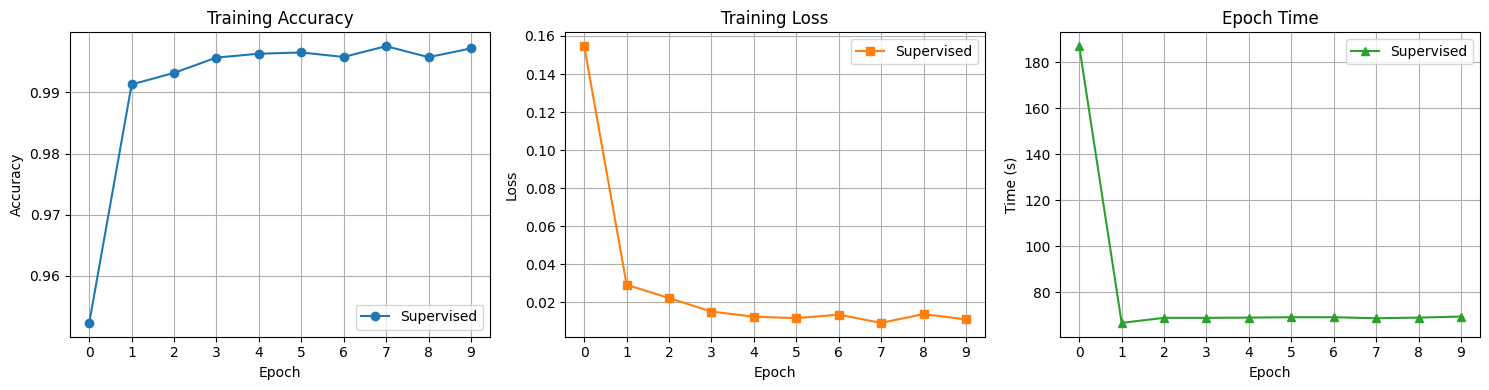

In [14]:
n_epochs = 10

model = SupervisedModelSpec(img_channels=1, num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loger = Loger("Supervised", n_epochs)

for epoch in range(n_epochs):
    start_time = time.time()
    loger.epoch_acc, loger.epoch_loss = train_classifier(model, loader, optimizer, device)
    loger.elapsed = time.time() - start_time
    loger.summary(epoch)

#  очистка
model.cpu()
torch.cuda.empty_cache()

## Task 2(2 points) (MF-CLAR)

Train the Multi-Format Contrastive Learning of Audio Representations model (implemented during the seminar) until convergence. Plot the loss and accuracy curves to verify that the training process has stabilized.

Multi-Format Contrastive Learning of Audio Representations (MF-CLAR) — это подход, где аудио и спектрограммы (или другие форматы) обучаются с контрастивной потерей, чтобы эмбеддинги разных форматов одного аудио были близки, а разных аудио — далеки. Основная идея: совместное обучение нескольких представлений аудио с контрастивным loss (например, InfoNCE).

1️⃣ формула лосс-функции. Для MF-CLAR обычно используют InfoNCE / NT-Xent loss между эмбеддингами разных форматов (например, аудио и спектрограмма):

In [15]:
def contrastive_loss(audio_emb, spec_emb, temperature=0.1):
    """
    Контрастивная потеря для пары аудио/спектрограмма
    audio_emb, spec_emb: [B, D]
    """
    # L2-нормализация
    audio_emb = F.normalize(audio_emb, dim=1)
    spec_emb = F.normalize(spec_emb, dim=1)
    
    # Косинусная схожесть [B, B]
    logits = torch.matmul(audio_emb, spec_emb.T) / temperature

    labels = torch.arange(audio_emb.size(0)).to(audio_emb.device)  # правильные пары
    loss_a2s = F.cross_entropy(logits, labels)
    loss_s2a = F.cross_entropy(logits.T, labels)
    
    return (loss_a2s + loss_s2a) / 2

2️⃣ Обертка модели Supervised
Добавим projection + classifier:

In [16]:
# ---------------------------------------
# Linear classifier для Supervised
# ---------------------------------------
class EvaluationHead(nn.Module):
    """
    Linear classifier head
    """
    def __init__(self, num_classes = 35):
        super(EvaluationHead, self).__init__()

        self.evaluation = nn.Sequential(
                    nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x = self.evaluation(x)
        return x

Цель — более сложный анализ, использование 1D и 2D данных и возможность получения эмбеддингов, вторая модель гибче и современнее.

In [17]:
# ---------------------------------------
# Supervised
# ---------------------------------------
class MFCLAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.encoder = Net(img_channels=1)
        self.classifier = EvaluationHead(num_classes)

    def forward(self, spec, wav):
        audio_emb, spec_emb, audio_feat, spec_feat = self.encoder(spec, wav)
        logits = self.classifier(audio_feat)
        return audio_emb, spec_emb, logits

Особенности:

1. Два источника информации:

    - spec — спектрограмма (2D)
    - wav — сырое аудио (1D)

    Энкодер Net возвращает несколько эмбеддингов:

    - audio_emb — представление аудио
    - spec_emb — представление спектрограммы
    - audio_feat, spec_feat — фичи для классификации
2. Линейный классификатор: EvaluationHead — один линейный слой [512 → num_classes].
3. Forward возвращает больше: эмбеддинги + logits. Это удобно для анализа, фьюжена или downstream-задач.
4. Используется torch.cuda.amp для ускоренного обучения с автоматическим смешанным типом (autocast) — важная оптимизация.
5. Train loop чуть более сложный: использует GradScaler для AMP, но в целом делает то же самое, что и первый: считает cross_entropy.

✅ Подходит, если нужно комбинировать спектрограммы и сырое аудио, получать эмбеддинги для других задач или использовать более продвинутый энкодер.

2️⃣  Функция обучения `train_supervised`

Теперь будем обучать две вещи одновременно:

* Классификацию (`cross_entropy` на `logits`)
* Контрастивную потерю (`contrastive_loss` между `audio_emb` и `spec_emb`)

Проблемы:

* Балансировка: alpha=0.5 может быть слишком большой или слишком маленькой для набора данных. Если contrastive_loss слишком сильная, модель может «забывать» классификацию, фокусируясь на согласовании эмбеддингов.
* Мешанина градиентов: В MFCLAR эмбеддинги и классификация используют одни и те же веса (self.output в Net). Контрастивная потеря может конфликтовать с кросс-энтропийной, особенно на небольших батчах.

In [18]:
def train_mfclar(model, loader, optimizer, device, alpha=0.1):
        """
        alpha - коэффициент для контрастивной потери
        """
        model.train()
        total, correct = 0, 0
        total_loss = 0.0
        scaler = torch.amp.GradScaler()

        for wavs, specs, labels in loader:
            wavs = wavs.to(device).unsqueeze(1)    # [B, 1, T]
            specs = specs.to(device).unsqueeze(1)  # [B, 1, F, T]
            labels = labels.to(device)

            optimizer.zero_grad()
            with torch.amp.autocast(device):
                audio_emb, spec_emb, logits = model(specs, wavs)
                ce_loss = F.cross_entropy(logits, labels)
                cl_loss = contrastive_loss(audio_emb, spec_emb)
                loss = ce_loss + alpha * cl_loss

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        return correct / total, total_loss / len(loader)

Теперь модель:

* Получает два формата: WAV + спектрограмма
* Обучается супервизорно (классификация)
* И контрастивно (эмбеддинги аудио и спектрограммы для одного примера сближаются)

3️⃣ Цикл обучения

Epoch 10/10
loss: 0.0409 | acc: 0.9885 | time: 118.13s


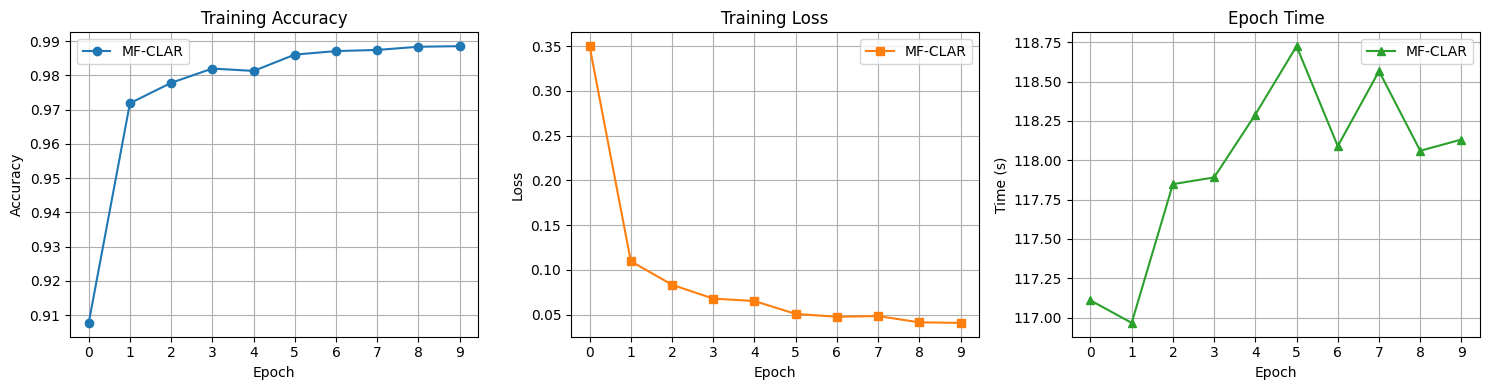

In [19]:
n_epochs = 10

model = MFCLAR(num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loger = Loger("MF-CLAR", n_epochs)

for epoch in range(n_epochs):
    start_time = time.time()
    loger.epoch_acc, loger.epoch_loss = train_mfclar(model, loader, optimizer, device)
    loger.elapsed = time.time() - start_time
    loger.summary(epoch)

# после завершения очищаем память GPU
model.cpu()
torch.cuda.empty_cache()

## Task 3(4 points)

Replace the InfoNCE loss in Multi-Format Contrastive Learning of Audio Representations with a Non-Contrastive Learning method.
Train the model until convergence, then plot the loss and accuracy curves to check that training has stabilized.

You can try one of the following NCL methods:
- BYOL([paper](https://arxiv.org/pdf/2006.07733))
- SimSiam([paper](https://arxiv.org/pdf/2011.10566))
- Barlow Twins([paper](https://arxiv.org/pdf/2103.03230))
- VicReg([paper](https://arxiv.org/pdf/2105.04906))

Feel free to use a more recent Non-Contrastive approach if you prefer—just explain briefly why you chose it.

---

### 3.0 Linear Evaluation

`train_linear` нужен для линейной оценки (linear evaluation) — это стандартный способ проверить, насколько полезные признаки выучил замороженный encoder после `SSL (self-supervised learning)`.

1️⃣ Почему замороженный encoder

SSL-модели, такие как SimSiam, VICReg, NCL и др., учат эмбеддинги без использования меток. Но мы хотим понять, насколько эти эмбеддинги полезны для реальной задачи классификации (например, распознавания цифр в AudioMNIST).

* `encoder.eval()` + `requires_grad=False` → веса encoder не меняются.
* Мы обучаем только линейный слой (classifier) на этих эмбеддингах.

2️⃣ Что делает linear evaluation
1. Берёт аудио и спектрограммы.
2. Пропускает их через замороженный encoder, чтобы получить фиксированные признаки (features).
3. Передаёт эти признаки через линейный классификатор (classifier), который обучается на известных метках.
4. Считает кросс-энтропию и accuracy, чтобы измерить качество признаков.

Это позволяет ответить на вопрос: «Насколько хорошо SSL-эмбеддинги разделяют классы на простой линейной границе?»

3️⃣ Почему это важно
* Proxy для качества SSL: Если линейный классификатор быстро достигает высокой точности, значит encoder выучил полезные и линейно отделимые признаки.
* Сравнение методов: Можно сравнивать, какой метод SSL лучше: VICReg, SimSiam, NCL, InfoNCE и т.д.
* Не требует дообучения всего encoder — экономия времени и ресурсов.

4️⃣ Резюме
* `train_linear` — это отдельная проверка, которая оценивает, насколько признаки из SSL полезны для downstream задачи.
* Это стандартный подход в SSL-исследованиях.

In [20]:
def train_linear(encoder, classifier, loader, optimizer, device):
    """
    Линейная оценка на замороженном encoder для AudioMNIST
    с использованием тройки (wavs, specs, labels)
    
    Args:
        encoder : замороженный encoder
        classifier : линейный классификатор
        loader : DataLoader отдающий (wavs, specs, labels)
        optimizer : оптимизатор для classifier
        device : torch.device
    
    Returns:
        avg_acc : accuracy
        avg_loss : средняя кросс-энтропия
    """
    encoder.eval()
    classifier.train()

    # Заморозим encoder
    for param in encoder.parameters():
        param.requires_grad = False
    # Разморозим classifier
    for param in classifier.parameters():
        param.requires_grad = True

    total_loss, total_correct, total_samples = 0.0, 0, 0

    for wavs, specs, labels in loader:
        wavs = wavs.to(device).unsqueeze(1)    # Приводим wav к [B, 1, T]
        specs = specs.to(device).unsqueeze(1)  # [B, 1, F, T]
        labels = labels.to(device)

        # Получаем признаки из encoder (замороженного и без градиентов)
        with torch.no_grad():
            _, _, feat, _ = encoder(specs, wavs)

        # Forward через classifier
        logits = classifier(feat)
        loss = F.cross_entropy(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_acc, avg_loss

In [21]:
def get_encoder(model):
    if hasattr(model, "encoder"):
        return model.encoder
    elif hasattr(model, "online"):
        return model.online
    elif hasattr(model, "encoder_q"):
        return model.encoder_q   # для MoCo
    else:
        raise ValueError(f"Нет энкодера у {type(model).__name__}")


---

### 3.1 Contrastive learning (InfoNCE) — [paper1](https://arxiv.org/pdf/2103.06508)
контрастивка (SimCLR-style): encoder → embeddings → contrastive loss

1️⃣ формула лосс-функции:
$$
L = −log \frac{e^{\frac{sim(z_i, z_j)}{\tau}}}{e^{\frac{\sum_k sim(z_i, z_k)}{\tau}}} 
$$

In [22]:
def info_nce_loss(z1, z2, temperature=0.1):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    logits = z1 @ z2.T / temperature
    labels = torch.arange(z1.size(0)).to(z1.device)
    return F.cross_entropy(logits, labels)

2️⃣ Contrastive InfoNCELModel

In [23]:
# ---------------------------------------
# Contrastive (InfoNCE / SimCLR)
# ---------------------------------------
class InfoNCEModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Net(img_channels=1)

    def forward(self, spec, wav):
        audio_emb, spec_emb, _, _ = self.encoder(spec, wav)
        return audio_emb, spec_emb

3️⃣ Обучение эмбеддингов (InfoNCE pretrain → Linear evaluation)

In [24]:
def train_info_nce(model, loader, optimizer, device, temperature=0.07):
    """
    Контрастивное обучение AudioMNIST с использованием тройки (wavs, specs, labels)
    будем аугментировать spec, а не wav
    
    Args:
        model : модель, возвращает (audio_emb, spec_emb)
        loader : DataLoader, отдающий (wavs, specs, labels)
        optimizer : оптимизатор
        device : torch.device
        temperature : коэффициент для InfoNCE
    
    Returns:
        avg_acc : accuracy по батчам
        avg_loss : средняя контрастивная потеря
    """
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for wavs, specs, _ in loader:  # игнорируем labels
        wavs = wavs.to(device).unsqueeze(1)    # [B, 1, T]
        specs = specs.to(device).unsqueeze(1)  # [B, 1, F, T]

        # Делаем два аугментированных вида каждого wav
        wav1, wav2 = augment(wavs), augment(wavs)  # функция augment должна работать с [B, 1, T]
        spec1, spec2 = augment(specs), augment(specs)

        # эмбеддинги
        z1_a, z1_s = model(spec1, wav1)  # audio, spec
        z2_a, z2_s = model(spec2, wav2)

        # если вдруг разная длина → фикс
        def align(a, b):
            min_len = min(a.size(-1), b.size(-1))
            return a[..., :min_len], b[..., :min_len]

        z1_a, z2_a = align(z1_a, z2_a)
        z1_s, z2_s = align(z1_s, z2_s)

        # pooling (очень желательно)
        z1_a = z1_a.mean(dim=-1)
        z2_a = z2_a.mean(dim=-1)
        z1_s = z1_s.mean(dim=-1)
        z2_s = z2_s.mean(dim=-1)

        # Контрастивная потеря
        loss = info_nce_loss(z1_a, z2_a) + info_nce_loss(z1_s, z2_s)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = wavs.size(0)
        total_loss += loss.item() * batch_size

        # Оценка accuracy (по эмбеддингам аудио)
        with torch.no_grad():
            z1 = F.normalize(z1_a, dim=1)
            z2 = F.normalize(z2_a, dim=1)
            logits = torch.cat([z1 @ z2.T, z2 @ z1.T], dim=0) / temperature
            labels = torch.arange(batch_size, device=device)
            labels = torch.cat([labels, labels], dim=0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_acc, avg_loss

4️⃣ InfoNCE Train-Loop:

In [ ]:
n_epochs = 30
lr = 1e-3
temperature = 0.07

model = InfoNCEModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loger = Loger("InfoNCEModel", n_epochs)

for epoch in range(n_epochs):
    start_time = time.time()
    
    loger.proxy_acc, loger.loss_val = train_info_nce(model, loader, optimizer, device, temperature)

    loger.elapsed = time.time() - start_time
    loger.summary(epoch)
'''
    history["loss"].append(loss_val)
    history["proxy_acc"].append(proxy_acc)

    print(f"Epoch {epoch+1}/{n_epochs} | Loss: {loss_val:.4f} | Proxy Acc: {proxy_acc:.4f} | Time: {elapsed:.2f}s")
'''

# после завершения очищаем память GPU
model.cpu()
torch.cuda.empty_cache()


---
### 3.2 Non-Contrastive Learning (NCL / BYOL-style) — [paper2](https://arxiv.org/pdf/2010.09542)
NCL = self-supervised с teacher–student (BYOL-like)


📌 Главное отличие: нет негативных пар → нет collapse через stop-gradient + predictor

1️⃣ NCL-Loss (cosine similarity)

Формула лосса:

$$
\mathcal{L} = 2 - 2 \cdot \frac{p}{\|p\|_2} \cdot \frac{z}{\|z\|_2}
$$

где используется нормализованное скалярное произведение (cosine similarity).

#### Интерпретация

Функция минимизирует расстояние между предсказанием $p$ и целевым представлением $z$:

- $p$ — выход **predictor** (обучаемая ветка)
- $z$ — выход **encoder** (с остановленным градиентом)


#### Связь с cosine similarity

Лосс эквивалентен:

$$
\mathcal{L} = 2 - 2 \cdot \cos(p, z)
$$

- при $\cos(p, z) = 1$ → $\mathcal{L} = 0$ (идеальное совпадение)
- при $\cos(p, z) = 0$ → $\mathcal{L} = 2$
- при $\cos(p, z) = -1$ → $\mathcal{L} = 4$

#### Stop-gradient

Ключевой момент:

- $z$ вычисляется с **остановкой градиента** (`detach()`)
- градиент проходит только через $p$

Это предотвращает коллапс представлений и стабилизирует обучение.

#### Симметричный вариант (как в SimSiam / BYOL)

Обычно используется двусторонний лосс:

$$
\mathcal{L} = \frac{1}{2} \mathcal{D}(p_1, z_2) + \frac{1}{2} \mathcal{D}(p_2, z_1)
$$

где:

$$
\mathcal{D}(p, z) = 2 - 2 \cdot \cos(p, z)
$$

#### Итог

- минимизирует угол между эмбеддингами  
- эквивалентен MSE для нормализованных векторов  
- не требует негативных примеров  
- использует stop-gradient для стабильности  

In [26]:
def ncl_loss(p, z):
    z = z.detach()
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return 2 - 2 * (p * z).sum(dim=1).mean()


2️⃣ NCL-Model (добавим predictor + EMA encoder)

In [27]:
# ---------------------------------------
# NCL / BYOL style
# ---------------------------------------
class NCLModel(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.online = Net(img_channels=1)
        self.target = copy.deepcopy(self.online)
        for p in self.target.parameters():
            p.requires_grad = False
        self.predictor = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )

    def forward(self, spec, wav):
        return self.online(spec, wav)


3️⃣ EMA update

In [28]:
@torch.no_grad()
def update_target(online, target, tau=0.99):
    for p, tp in zip(online.parameters(), target.parameters()):
        tp.data = tau * tp.data + (1 - tau) * p.data

4️⃣ Обучение эмбеддингов (NCL pretrain → Linear evaluation)

In [29]:
def train_ncl(model, loader, optimizer, device, temperature=0.07):
    """
    NCL (Neighbor Contrastive Learning) обучение для AudioMNIST
    с использованием тройки (wavs, specs, labels)
    
    Args:
        model : модель с методами online, target и predictor
        loader : DataLoader отдающий (wavs, specs, labels)
        optimizer : оптимизатор
        device : torch.device
        temperature : коэффициент для оценки accuracy

    Returns:
        avg_acc : accuracy по батчам
        avg_loss : средняя потеря NCL
    """
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for wavs, specs, _ in loader:  # игнорируем labels
        wavs = wavs.to(device).unsqueeze(1)    # [B, 1, T]
        specs = specs.to(device).unsqueeze(1)  # [B, 1, F, T]

        # Делаем два аугментированных вида 
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1, spec2 = augment(specs), augment(specs)

        # online + predictor
        z1_a, z1_s, _, _ = model.online(spec1, wav1)
        z2_a, z2_s, _, _ = model.online(spec2, wav2)

        # выравнивание длины (если есть Conv рассинхрон)
        def align(a, b):
            min_len = min(a.size(-1), b.size(-1))
            return a[..., :min_len], b[..., :min_len]

        z1_a, z2_a = align(z1_a, z2_a)

        # 🔥 pooling (обязательно для стабильности)
        z1_a = z1_a.mean(dim=-1)
        z2_a = z2_a.mean(dim=-1)

        # predictor
        p1, p2 = model.predictor(z1_a), model.predictor(z2_a)

        # target эмбеддинги
        with torch.no_grad():
            t1_a, _, _, _ = model.target(spec1, wav1)
            t2_a, _, _, _ = model.target(spec2, wav2)

            t1_a, t2_a = align(t1_a, t2_a)
            t1_a = t1_a.mean(dim=-1)
            t2_a = t2_a.mean(dim=-1)
        
        # NCL loss
        loss = ncl_loss(p1, t2_a) + ncl_loss(p2, t1_a)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # обновляем EMA update target сеть
        update_target(model.online, model.target)

        batch_size = wavs.size(0)
        total_loss += loss.item() * batch_size

        # accuracy (по аудио-эмбеддингам)
        with torch.no_grad():
            z1 = F.normalize(p1, dim=1)
            z2 = F.normalize(t2_a, dim=1)

            logits = torch.cat([z1 @ z2.T, z2 @ z1.T], dim=0) / temperature
            labels = torch.arange(batch_size, device=device)
            labels = torch.cat([labels, labels], dim=0)
            
            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_acc, avg_loss

5️⃣ NCL Train-Loop

In [ ]:
n_epochs = 30
lr = 1e-3
temperature = 0.07

# ===== Модель и оптимизатор =====
model = NCLModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loger = Loger("NCL", n_epochs)

for epoch in range(n_epochs):
    start_time = time.time()

    # ===== 1. SSL обучение через train_ncl =====
    loger.proxy_acc, loger.epoch_loss = train_ncl(model, loader, optimizer, device, temperature)

    loger.elapsed = time.time() - start_time

    # ===== 2. Linear evaluation =====
    encoder = get_encoder(model)  # линейная оценка на online encoder
    for param in encoder.parameters():
        param.requires_grad = False

    classifier = EvaluationHead(num_classes=10).to(device)
    optimizer_lin = torch.optim.Adam(classifier.parameters(), lr=1e-3)

    loger.lin_acc, loger.lin_loss = train_linear(encoder, classifier, loader, optimizer_lin, device)
    loger.summary(epoch)
    '''
    # ===== 3. История =====
    history["NCL"]["loss"].append(ncl_loss_val)
    history["NCL"]["proxy_acc"].append(proxy_acc)
    history["NCL"]["linear_acc"].append(lin_acc)
    history["NCL"]["linear_loss"].append(lin_loss)
    history["NCL"]["time"].append(elapsed)

    # ===== 4. Логи =====
    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"NCL Loss: {ncl_loss_val:.4f} | Proxy Acc: {proxy_acc:.4f} | Time: {elapsed:.2f}s")
    print(f"Linear Eval → Acc: {lin_acc:.4f}, Loss: {lin_loss:.4f}")

    # ===== 5. Графики =====
    plot(
        [history["NCL"]["proxy_acc"], history["NCL"]["linear_acc"]],
        [history["NCL"]["loss"], history["NCL"]["linear_loss"]],
        [history["NCL"]["time"], history["NCL"]["time"]],
        labels=["Proxy NCL", "Linear Eval"]
    )
    '''
    # 🔥 Очистка
    del classifier, optimizer_lin
    torch.cuda.empty_cache()

# 🔥 Финальная очистка
model.cpu()
torch.cuda.empty_cache()

### 3.4 SimSiam — [paper](https://arxiv.org/pdf/2011.10566)
👉 сейчас NCL ≈ BYOL. Теперь добавим SimSiam (без EMA)

1️⃣ SimSiam Loss

Формула симметричного лосса из статьи:
$$
\mathcal{L} = \frac{1}{2} \mathcal{D}(p_1, z_2) + \frac{1}{2} \mathcal{D}(p_2, z_1)
$$
где $\mathcal{D}(p, z) = - \frac{p}{\|p\|_2} \cdot \frac{z}{\|z\|_2}$ (отрицательное косинусное сходство).

*   $\mathcal{D}(p_1, z_2)$ - predictor применяется к выходу левой ветки, а правая ветка "заморожена" (stop-gradient)
*   $\mathcal{D}(p_2, z_1)$ - зеркальная версия.

Используя симметричый лосс,  заставляем обе ветки учиться друг у друга.
- Левая ветка предсказывает правую.
- Правая - предсказывает левую.

In [31]:
def simsiam_loss(p, z):
    z = z.detach()  # 🔥 ВАЖНО
    p = F.normalize(p, dim=1)
    z = F.normalize(z, dim=1)
    return -(p * z).sum(dim=1).mean()

2️⃣ SimSiam Model

In [32]:
class SimSiamModel(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.encoder = Net(img_channels=1)

        self.projector = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, emb_dim)
        )

        self.predictor = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )

    def forward(self, spec, wav):
        _, _, feat, _ = self.encoder(spec, wav)
        z = self.projector(feat)
        p = self.predictor(z)
        return p, z.detach()

3️⃣ SimSiam Train-функция

In [33]:
def train_simsiam(model, loader, optimizer, device):
    """
    SimSiam обучение для AudioMNIST с тройкой (wavs, specs, labels)
    
    Args:
        model : модель, возвращает (p, z)
        loader : DataLoader отдающий (wavs, specs, labels)
        optimizer : оптимизатор
        device : torch.device
    
    Returns:
        avg_acc : всегда 0 (SimSiam не использует labels)
        avg_loss : средняя потеря
    """
    model.train()
    total_loss, total_samples = 0.0, 0

    for wavs, specs, _ in loader:  # labels игнорируем
        wavs = wavs.to(device).unsqueeze(1)    # [B, 1, T]
        specs = specs.to(device).unsqueeze(1)  # [B, 1, F, T]

         # аугментации без пересчёта mel
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1, spec2 = augment(specs), augment(specs)

        # Forward pass через SimSiam
        p1, z1 = model(spec1, wav1)
        p2, z2 = model(spec2, wav2)

       # выравнивание (если есть разный T)
        def align(a, b):
            min_len = min(a.size(-1), b.size(-1))
            return a[..., :min_len], b[..., :min_len]

        p1, z2 = align(p1, z2)
        p2, z1 = align(p2, z1)

        # pooling (ОБЯЗАТЕЛЬНО для SimSiam)
        p1 = p1.mean(dim=-1)
        p2 = p2.mean(dim=-1)
        z1 = z1.mean(dim=-1)
        z2 = z2.mean(dim=-1)

        # stop-grad как в SimSiam
        z1 = z1.detach()
        z2 = z2.detach()
        
        # SimSiam loss
        loss = 0.5 * simsiam_loss(p1, z2) + 0.5 * simsiam_loss(p2, z1)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = wavs.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    avg_acc = 0  # SimSiam не использует labels
    return avg_acc, avg_loss

4️⃣ SimSiam Train-Loop

In [ ]:
n_epochs = 30
lr = 1e-3

# ===== Модель и оптимизатор =====
model = SimSiamModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loger = Loger ("SimSiam", n_epochs)

for epoch in range(n_epochs):
    start_time = time.time()

    # ===== 1. SSL обучение через train_simsiam =====
    loger.proxy_acc, loger.epoch_loss = train_simsiam(model, loader, optimizer, device)

    loger.elapsed = time.time() - start_time

    # ===== 2. Linear evaluation =====
    encoder = get_encoder(model)  # важно: encoder внутри SimSiam
    for param in encoder.parameters():
        param.requires_grad = False

    classifier = EvaluationHead(num_classes=10).to(device)
    optimizer_lin = torch.optim.Adam(classifier.parameters(), lr=1e-3)

    loger.lin_acc, loger.lin_loss = train_linear(encoder, classifier, loader, optimizer_lin, device)
    loger.summary(epoch)
    '''
    # ===== 3. Сохраняем историю =====
    history["SimSiam"]["loss"].append(simsiam_loss_val)
    history["SimSiam"]["proxy_acc"].append(proxy_acc)  # всегда 0 для SimSiam
    history["SimSiam"]["linear_acc"].append(lin_acc)
    history["SimSiam"]["linear_loss"].append(lin_loss)
    history["SimSiam"]["time"].append(elapsed)

    # ===== 4. Вывод =====
    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"SimSiam Loss: {simsiam_loss_val:.4f} | Proxy Acc: {proxy_acc:.4f} | Time: {elapsed:.2f}s")
    print(f"Linear Eval → Acc: {lin_acc:.4f}, Loss: {lin_loss:.4f}")

    # ===== 5. Графики =====
    plot(
        [history["SimSiam"]["proxy_acc"], history["SimSiam"]["linear_acc"]],
        [history["SimSiam"]["loss"], history["SimSiam"]["linear_loss"]],
        [history["SimSiam"]["time"], history["SimSiam"]["time"]],
        labels=["Proxy SimSiam", "Linear Eval"]
    )
    '''
    # 🔥 Очистка
    del classifier, optimizer_lin
    torch.cuda.empty_cache()

# 🔥 Финальная очистка
model.cpu()
torch.cuda.empty_cache()


---

### 3.5 VICReg — [paper](https://arxiv.org/pdf/2105.04906)
✅ VICReg tuning (даёт реальный буст:  +10–20% accuracy): 
* Batch size ≥ 64 (очень важно)
* normalize вход: `z = F.normalize(z, dim=1)`
* Добавить projector (важно!): 
```
self.projector = nn.Sequential(
    nn.Linear(512, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Linear(512, 128)
)
```
и использовать `projector output`, а не `raw features`.
* Правильные коэффициенты (sim_coeff, var_coeff, cov_coeff):

In [35]:
sim_coeff = 25
var_coeff = 25
cov_coeff = 1

1️⃣ VICReg Loss

🧠 1. Идея

VICReg (Variance-Invariance-Covariance Regularization) стремится к трём целям:

1. Сделать эмбеддинги двух аугментаций **похожими** (Invariance)
2. Обеспечить **разнообразие признаков** (Variance)
3. Уменьшить **корреляцию между признаками** (Covariance)

👉 ключевая цель: получить **информативные и недекоррелированные признаки** без использования негативных примеров.

📉 2. Функция потерь

Полная формула VICReg:

$$
\mathcal{L}_\text{VICReg} = 
\lambda_\text{sim} \, \mathcal{L}_\text{sim} +
\lambda_\text{var} \, \mathcal{L}_\text{var} +
\lambda_\text{cov} \, \mathcal{L}_\text{cov}
$$

где:

- $\mathcal{L}_\text{sim}$ — **similarity loss** (инвариантность)  
- $\mathcal{L}_\text{var}$ — **variance loss** (стимулирует стандартное отклонение > 1)  
- $\mathcal{L}_\text{cov}$ — **covariance loss** (уменьшает корреляцию между признаками)  
- $\lambda_\text{sim}, \lambda_\text{var}, \lambda_\text{cov}$ — коэффициенты для балансировки

🔗 3. Инвариантность (Similarity)

$$
\mathcal{L}_\text{sim} = \text{MSE}(z_1, z_2)
$$

👉 заставляет эмбеддинги двух аугментаций совпадать:  
- $z_1 \approx z_2$  
- сохраняется смысловая информация

📊 4. Разнообразие признаков (Variance)

$$
\mathcal{L}_\text{var} = 
\frac{1}{D} \sum_{i=1}^D \Big[ \text{ReLU}(1 - \sigma(z_1^i)) + \text{ReLU}(1 - \sigma(z_2^i)) \Big]
$$

где $\sigma(z)$ — стандартное отклонение признака по батчу.  

👉 цель:  
- Каждый признак должен быть разнообразным  
- Избегаем схлопывания всех признаков в одно значение

🔗 5. Редукция корреляции (Covariance)

1. Центрируем эмбеддинги:

$$
\tilde{z} = z - \text{mean}(z)
$$

2. Вычисляем ковариационную матрицу:

$$
C = \frac{\tilde{z}^\top \tilde{z}}{N-1}
$$

3. Берём **off-diagonal элементы** и минимизируем их:

$$
\mathcal{L}_\text{cov} = \frac{1}{D^2 - D} \sum_{i \neq j} C_{ij}^2
$$

👉 это уменьшает корреляцию между разными признаками → более независимые признаки.

⚖️ 6. Роль коэффициентов

- $\lambda_\text{sim}$ — приоритет на совпадение эмбеддингов  
- $\lambda_\text{var}$ — приоритет на разнообразие признаков  
- $\lambda_\text{cov}$ — приоритет на независимость признаков  

Баланс между ними важен: сохранение сходства + разнообразие + недекорреляция.

🧠 7. Почему это работает

- Избегаем коллапса: если все признаки одинаковые → высокая потеря variance и covariance  
- Признаки вынуждены быть **разными, но согласованными по смыслу**  
- Не нужны негативные примеры, как в contrastive learning

📊 8. Геометрическая интуиция

- Признаки распределены в пространстве с **разнообразием и ортогональностью**  
- Каждый нейрон кодирует **разную информацию**, но эмбеддинги двух аугментаций остаются согласованными

⚠️ 9. Ограничения

- Чувствителен к размеру батча  
- Требует хорошей нормализации  
- При маленьком batch качество может падать

🏁 Вывод

VICReg:

- Максимизирует сходство между аугментациями  
- Минимизирует корреляцию между признаками  
- Сохраняет разнообразие признаков  
- Не использует негативные примеры  

👉 идея: "сделай признаки совпадающими, но независимыми и разнообразными"

In [36]:
def vicreg_loss(z1, z2, sim_coeff=25, var_coeff=25, cov_coeff=1):
    # invariance (MSE между эмбеддингами)
    sim_loss = F.mse_loss(z1, z2)

    # variance (стимулируем std > 1)
    std_z1 = torch.sqrt(z1.var(dim=0) + 1e-4)
    std_z2 = torch.sqrt(z2.var(dim=0) + 1e-4)
    var_loss = torch.mean(F.relu(1 - std_z1)) + torch.mean(F.relu(1 - std_z2))

    # covariance (редуцируем корреляцию между признаками)
    z1 = z1 - z1.mean(dim=0)
    z2 = z2 - z2.mean(dim=0)
    cov_z1 = (z1.T @ z1) / (z1.size(0) - 1)
    cov_z2 = (z2.T @ z2) / (z2.size(0) - 1)

    # off-diagonal элементы
    off_diag = lambda x: x.flatten()[:-1].view(x.size(0)-1, x.size(1)+1)[:,1:].flatten()
    cov_loss = off_diag(cov_z1).pow(2).mean() + off_diag(cov_z2).pow(2).mean()

    return sim_coeff * sim_loss + var_coeff * var_loss + cov_coeff * cov_loss

2️⃣ Добавляем модель VICRegModel

In [37]:
class VICRegModel(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.encoder = NCLModel(emb_dim=emb_dim)  # без .encoder

    def forward(self, x):
        return self.encoder(x)

3️⃣ VICReg Train-функция

In [38]:
def train_vicreg(model, loader, optimizer, device):
    """
    VICReg обучение для AudioMNIST с тройкой (wavs, specs, labels)
    
    Args:
        model : модель с методом encoder
        loader : DataLoader отдающий (wavs, specs, labels)
        optimizer : оптимизатор
        device : torch.device
    
    Returns:
        avg_acc : proxy accuracy по аудио-эмбеддингам
        avg_loss : средняя VICReg потеря
    """
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for wavs, specs, _ in loader:
        # готовые данные
        wavs = wavs.to(device).unsqueeze(1)    # [B, 1, T]
        specs = specs.to(device).unsqueeze(1)  # [B, 1, F, T]

        # аугментации без пересчёта mel
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1, spec2 = augment(specs), augment(specs)

        # embeddings
        z1_a, z1_s, _, _ = model.encoder(spec1, wav1)
        z2_a, z2_s, _, _ = model.encoder(spec2, wav2)

        # выравнивание длины
        def align(a, b):
            min_len = min(a.size(-1), b.size(-1))
            return a[..., :min_len], b[..., :min_len]

        z1_a, z2_a = align(z1_a, z2_a)
        z1_s, z2_s = align(z1_s, z2_s)

        # pooling (ОБЯЗАТЕЛЬНО для VICReg)
        z1_a = z1_a.mean(dim=-1)
        z2_a = z2_a.mean(dim=-1)
        z1_s = z1_s.mean(dim=-1)
        z2_s = z2_s.mean(dim=-1)

        # VICReg loss
        loss = vicreg_loss(z1_a, z2_a) + vicreg_loss(z1_s, z2_s)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batch_size = wavs.size(0)
        total_loss += loss.item() * batch_size

        # proxy accuracy
        with torch.no_grad():
            z1 = F.normalize(z1_a, dim=1)
            z2 = F.normalize(z2_a, dim=1)

            logits = torch.cat([z1 @ z2.T, z2 @ z1.T], dim=0)
            labels = torch.arange(batch_size, device=device)
            labels = torch.cat([labels, labels], dim=0)

            preds = logits.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples
    return avg_acc, avg_loss

4️⃣ VICReg Train Loop

In [ ]:
n_epochs = 30
lr = 1e-3

# ===== Модель и оптимизатор =====
model = VICRegModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loger = Loger("VICReg", n_epochs)
'''
# ===== История =====
history = {
    "VICReg": {"loss": [], "proxy_acc": [], "linear_acc": [], "linear_loss": [], "time": []}
}
'''
for epoch in range(n_epochs):
    start_time = time.time()

    # ===== 1. SSL обучение через train_vicreg =====
    loger.proxy_acc, loger.epoch_loss = train_vicreg(model, loader, optimizer, device)

    loger.elapsed = time.time() - start_time

    # ===== 2. Linear evaluation =====
    encoder = get_encoder(model)

    for param in encoder.parameters():
        param.requires_grad = False  # замораживаем encoder

    classifier = EvaluationHead(num_classes=10).to(device)
    optimizer_lin = torch.optim.Adam(classifier.parameters(), lr=1e-3)

    loger.lin_acc, loger.lin_loss = train_linear(encoder, classifier, loader, optimizer_lin, device)
    loger.summary(epoch)
    '''
    # ===== 3. Сохраняем историю =====
    history["VICReg"]["loss"].append(vicreg_loss_val)
    history["VICReg"]["proxy_acc"].append(proxy_acc)
    history["VICReg"]["linear_acc"].append(lin_acc)
    history["VICReg"]["linear_loss"].append(lin_loss)
    history["VICReg"]["time"].append(elapsed)

    # ===== 4. Вывод =====
    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"VICReg Loss: {vicreg_loss_val:.4f} | Proxy Acc: {proxy_acc:.4f} | Time: {elapsed:.2f}s")
    print(f"Linear Eval → Acc: {lin_acc:.4f}, Loss: {lin_loss:.4f}")

    # ===== 5. Графики =====
    plot(
        [history["VICReg"]["proxy_acc"], history["VICReg"]["linear_acc"]],
        [history["VICReg"]["loss"], history["VICReg"]["linear_loss"]],
        [history["VICReg"]["time"], history["VICReg"]["time"]],
        labels=["Proxy VICReg", "Linear Eval"]
    )
    '''
    # 🔥 Очистка памяти
    del classifier, optimizer_lin
    torch.cuda.empty_cache()

# 🔥 После завершения — убираем модель с GPU
model.cpu()
torch.cuda.empty_cache()

##### 🔥 Почему VICReg почти всегда стабилен (роль variance term)

🧠 1. Что такое collapse

Коллапс — это ситуация, когда модель выдаёт одно и то же представление для всех входов:

$$
z(x) = \text{const}
$$

Тогда:
- cosine similarity = 1  
- MSE = 0  
- loss минимален  

Но представления становятся бесполезными ❌

⚠️ 2. Почему другие методы могут коллапсировать

SimSiam / NCL минимизируют:

$$
\cos(p, z)
$$

Если:
$$
p = z = \text{const}
$$

→ loss минимален → возможен коллапс

👉 Они спасаются:
- stop-gradient  
- predictor  

Но это:
- неявные механизмы  
- иногда нестабильны  

🔥 3. Что делает VICReg иначе

VICReg разбивает задачу на три части:

$$
\mathcal{L} =
\lambda \cdot \text{invariance} +
\mu \cdot \text{variance} +
\nu \cdot \text{covariance}
$$

💣 4. Ключевой компонент: variance term

Variance loss:

$$
\text{VarLoss} = \frac{1}{D} \sum \max(0, 1 - \sigma(z))
$$

где:
- $\sigma(z)$ — стандартное отклонение по батчу  

🧩 5. Почему это предотвращает collapse

Рассмотрим коллапс:

$$
z = \text{const}
$$

Тогда:

$$
\text{Var}(z) = 0 \Rightarrow \sigma = 0
$$

Подставляем:

$$
\max(0, 1 - 0) = 1
$$

👉 variance loss становится большим

📊 Итог

| Состояние | variance loss |
|----------|--------------|
| нормальные фичи | ≈ 0 |
| низкая дисперсия | > 0 |
| коллапс | 🔥 большой штраф |

⚖️ 6. Главное отличие

👉 VICReg использует **прямое ограничение**, а не эвристику

| Метод | Как избегает collapse |
|------|----------------------|
| SimSiam | stop-gradient |
| BYOL | EMA teacher |
| Barlow Twins | decorrelation |
| **VICReg** | 🔥 штраф за низкую дисперсию |

🔍 7. Геометрическая интуиция

- Без variance term → все точки могут схлопнуться в одну  
- С variance term → точки обязаны быть "размазаны"  

👉 пространство не может деградировать в одну точку

📦 8. Сравнение с Barlow Twins

**Barlow Twins:**
- убирает корреляции  
- но не контролирует variance  

👉 возможна ситуация:
- все признаки ≈ 0  
- но некоррелированы  

**VICReg:**
1. заставляет variance > 1  
2. затем убирает корреляции  

👉 более надёжный подход


 9. Почему работает на маленьких batch

Variance считается по батчу:

$$
\text{Var}(z)
$$

👉 даже маленький batch даёт сигнал:
- "ты схлопнулся"
- "увеличь разброс"

🧠 10. Интуиция

- SimSiam → "сделай одинаковыми"  
- Barlow → "сделай независимыми"  
- **VICReg → "сделай одинаковыми, но не одинаковыми"**

🏁 Вывод

VICReg стабилен, потому что:

- напрямую запрещает collapse  
- даёт сильный градиент при схлопывании  
- не зависит от архитектурных трюков

---

### 3.4 Barlow Twins  — [paper](https://arxiv.org/pdf/2103.03230)

1️⃣ Barlow Twins Loss

🧠 1. Идея

Barlow Twins стремится:

- сделать представления двух аугментаций **похожими**
- при этом сделать разные признаки **независимыми**

👉 ключевая цель: получить **информативные и декоррелированные признаки**


📐 2. Нормализация

Сначала эмбеддинги нормализуются по батчу:

$$
\tilde{z} = \frac{z - \mu}{\sigma}
$$

где:
- $\mu$ — среднее по батчу  
- $\sigma$ — стандартное отклонение  

👉 это делает признаки сопоставимыми


🔗 3. Cross-correlation матрица

Вычисляется матрица корреляции:

$$
C = \frac{1}{N} Z_1^\top Z_2
$$

где:
- $Z_1, Z_2 \in \mathbb{R}^{N \times D}$
- $C \in \mathbb{R}^{D \times D}$

👉 $C_{ij}$ показывает, насколько признак $i$ из одной ветки коррелирует с признаком $j$ из другой


 🎯 4. Целевая матрица

Идеально:

$$
C = I
$$

где $I$ — единичная матрица

Это означает:

- диагональ = 1 → одинаковые признаки совпадают  
- вне диагонали = 0 → признаки независимы  


 📉 5. Функция потерь

$$
\mathcal{L} =
\underbrace{\sum_i (1 - C_{ii})^2}_{\text{invariance}} +
\lambda \cdot
\underbrace{\sum_{i \neq j} C_{ij}^2}_{\text{redundancy reduction}}
$$


🔍 6. Разбор компонентов

🔹 Диагональный член (invariance)

$$
(1 - C_{ii})^2
$$

👉 заставляет:
- одинаковые признаки совпадать  
- $z_1^i \approx z_2^i$

🔹 Внедиагональный член (decorrelation)

$$
C_{ij}^2, \quad i \neq j
$$

👉 штрафует:
- корреляции между разными признаками → уменьшает redundancy


⚖️ 7. Роль $\lambda$ (lambd = 5e-3)

* маленькое значение → приоритет на совпадение признаков
* большое значение → сильнее штраф за корреляцию между признаками
* балансирует: совпадение представлений + независимость признаков


🧠 8. Почему это работает

Barlow Twins избегает коллапса, потому что если все признаки одинаковые → корреляции вне диагонали большие → высокий штраф

👉 модель вынуждена сохранять разнообразие признаков, не схлопываться


📊 9. Геометрическая интуиция

Модель делает:
* оси признаков ортогональными
* распределение — "размазано" в пространстве

👉 каждый нейрон кодирует разную информацию


⚠️ 10. Ограничения
* чувствителен к размеру батча
* требует хорошей нормализации
* может деградировать при маленьком batch


🏁 Вывод

Barlow Twins:

* максимизирует сходство между аугментациями
* минимизирует корреляцию между признаками
* не требует негативных примеров

👉 идея: "сделай признаки совпадающими, но независимыми"



In [40]:
def barlow_loss(z1, z2, lambd=5e-3):
    z1 = (z1 - z1.mean(0)) / z1.std(0)
    z2 = (z2 - z2.mean(0)) / z2.std(0)

    N, D = z1.size()
    c = (z1.T @ z2) / N

    on_diag = torch.diagonal(c).add_(-1).pow_(2).sum()
    off_diag = (c - torch.eye(D, device=z1.device)).pow(2).sum() - on_diag

    return on_diag + lambd * off_diag

2️⃣ Добавляем модель BarlowModel

Уже есть encoder-модель (как в NCL / VICReg), можно использовать её:

In [41]:
class BarlowModel(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        # Используем онлайн энкодер NCL
        self.encoder = NCLModel(emb_dim=emb_dim).online

3️⃣ Barlow Train+Proxy-функция:

In [42]:
def train_barlow(model, loader, optimizer, device):
    """
    Обучение Barlow + вычисление Proxy accuracy за один проход по loader.
    Спектрограммы берутся из Dataset, а не пересчитываются каждый раз.
    
    Возвращает: средний loss по батчам, proxy accuracy.
    Returns:
        avg_loss : средняя Barlow loss
        proxy_acc : proxy accuracy
    """
    model.train()
    total_loss = 0.0
    total_correct, total_samples = 0, 0

    for wavs, specs, _ in loader:  # labels игнорируем
        # === 1. Перенос на устройство ===
        wavs = wavs.to(device).unsqueeze(1)   # [B, 1, T]
        specs = specs.to(device).unsqueeze(1) # [B, 1, F, T]

        # === 2. Аугментации ===
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1, spec2 = augment(specs), augment(specs)

        # === 3. Энкодер ===
        z1_a, _, _, _ = model.encoder(spec1, wav1)
        z2_a, _, _, _ = model.encoder(spec2, wav2)

        # === 4. Barlow loss ===
        loss = barlow_loss(z1_a, z2_a)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * wavs.size(0)

        # === 5. Proxy accuracy ===
        with torch.no_grad():
            z1 = F.normalize(z1_a, dim=1)
            z2 = F.normalize(z2_a, dim=1)
            logits = torch.cat([z1 @ z2.T, z2 @ z1.T], dim=0)

            batch_size = wavs.size(0)
            labels_proxy = torch.arange(batch_size, device=device)
            labels_proxy = torch.cat([labels_proxy, labels_proxy], dim=0)

            preds = logits.argmax(dim=1)
            total_correct += (preds == labels_proxy).sum().item()
            total_samples += labels_proxy.size(0)

    avg_loss = total_loss / total_samples
    proxy_acc = total_correct / total_samples
    return avg_loss, proxy_acc

4️⃣ Barlow Train-Loop

In [ ]:
n_epochs = 30
lr = 1e-3

# ===== Модель и оптимизатор =====
model = BarlowModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loger = Loger("Barlow", n_epochs)
'''
# ===== История =====
history = {
    "Barlow": {"loss": [], "proxy_acc": [], "linear_acc": [], "linear_loss": [], "time": []}
}
'''
for epoch in range(n_epochs):
    start_time = time.time()

    loger.epoch_loss, loger.proxy_acc = train_barlow(model, loader, optimizer, device)

    # ===== Linear evaluation =====
    # encoder = model.encoder if hasattr(model, "encoder") else model.online
    encoder = get_encoder(model)
    for param in encoder.parameters():
        param.requires_grad = False

    classifier = EvaluationHead(num_classes=10).to(device)
    optimizer_lin = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    loger.lin_acc, loger.lin_loss = train_linear(encoder, classifier, loader, optimizer_lin, device)
    loger.summary(epoch)
    '''
    # ===== 4. История =====
    history["Barlow"]["loss"].append(barlow_loss_val)
    history["Barlow"]["proxy_acc"].append(proxy_acc)
    history["Barlow"]["linear_acc"].append(lin_acc)
    history["Barlow"]["linear_loss"].append(lin_loss)
    history["Barlow"]["time"].append(elapsed)

    # ===== 5. Логи =====
    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"Barlow Loss: {barlow_loss_val:.4f} | Proxy Acc: {proxy_acc:.4f} | Time: {elapsed:.2f}s")
    print(f"Linear Eval → Acc: {lin_acc:.4f}, Linear Loss: {lin_loss:.4f}")

    # ===== 6. Графики =====
    plot(
        [history["Barlow"]["proxy_acc"], history["Barlow"]["linear_acc"]],
        [history["Barlow"]["loss"], history["Barlow"]["linear_loss"]],
        [history["Barlow"]["time"], history["Barlow"]["time"]],
        labels=["Proxy Barlow", "Linear Eval"]
    )
    '''
    # 🔥 Очистка памяти
    del classifier, optimizer_lin
    torch.cuda.empty_cache()

# 🔥 Освобождаем GPU
model.cpu()
torch.cuda.empty_cache()

### 3.5 NCL vs SimSiam vs BYOL vs Barlow Twins vs VICReg
Все методы:
- не используют негативные примеры  
- учатся на двух аугментациях  
- избегают collapse разными способами  

🧠 Общая идея

| Метод | Идея |
|------|------|
| **SimSiam** | predictor учится предсказывать stop-gradient target |
| **BYOL** | добавляем teacher (EMA encoder) |
| **NCL** | упрощённый SimSiam с cosine loss |
| **Barlow Twins** | делаем cross-correlation ≈ identity |
| **VICReg** | баланс: invariance + variance + decorrelation |

⚙️ Архитектура

| Компонент        | SimSiam | BYOL | NCL | Barlow | VICReg |
|------------------|--------|------|-----|--------|--------|
| Encoder          | ✅     | ✅   | ✅  | ✅     | ✅     |
| Projection head  | ✅     | ✅   | ✅  | ✅     | ✅     |
| Predictor        | ✅     | ✅   | ✅  | ❌     | ❌     |
| Stop-gradient    | ✅     | ✅   | ✅  | ❌     | ❌     |
| EMA (teacher)    | ❌     | ✅   | ❌  | ❌     | ❌     |


📉 Loss функции

* SimSiam
$$
\mathcal{L} = - \cos(p, z)
$$

* NCL
$$
\mathcal{L} = 2 - 2 \cdot \cos(p, z)
$$

* BYOL
$$
\mathcal{L} = \| p - z \|_2^2
$$

* Barlow Twins
$$
\mathcal{L} = \sum_i (1 - c_{ii})^2 + \lambda \sum_{i \neq j} c_{ij}^2
$$

где $c$ — cross-correlation матрица.

* VICReg
$$
\mathcal{L} =
\lambda \cdot \text{invariance} +
\mu \cdot \text{variance} +
\nu \cdot \text{covariance}
$$

🔗 Связь между методами

👉 Первая группа (pairwise matching):

$$
\| p - z \|^2 = 2 - 2 \cdot \cos(p, z)
$$

- **BYOL ≈ NCL**
- **SimSiam ≈ NCL (масштаб)**

👉 Вторая группа (distribution-level):

- **Barlow Twins** → decorrelation через cross-correlation  
- **VICReg** → явно разделяет цели (variance + covariance)

🧨 Как избегают collapse

| Метод | Механизм |
|------|----------|
| **SimSiam** | stop-gradient + predictor (архитектура) |
| **BYOL** | EMA teacher |
| **NCL** | только stop-gradient |
| **Barlow** | decorrelation (off-diagonal → 0) |
| **VICReg** | variance constraint + decorrelation |


📊 Стабильность обучения

| Метод | Стабильность |
|------|-------------|
| **BYOL** | 🔥🔥🔥 |
| **VICReg** | 🔥🔥🔥 |
| **Barlow Twins** | 🔥🔥 |
| **SimSiam** | 🔥🔥 |
| **NCL** | 🔥 |


⚡ Чувствительность к batch size

| Метод | Batch size |
|------|-----------|
| **Barlow Twins** | ❗ требует большой batch |
| **VICReg** | 👍 устойчив |
| **BYOL** | 👍 устойчив |
| **SimSiam** | 👍 средне |
| **NCL** | 👍 средне |


🚀 Сложность

| Метод | Сложность |
|------|----------|
| **NCL** | 🟢 самый простой |
| **SimSiam** | 🟡 |
| **Barlow Twins** | 🟡 |
| **VICReg** | 🟠 |
| **BYOL** | 🔴 самый сложный |


🚀 Когда что использовать

- **NCL** → быстрые эксперименты, baseline  
- **SimSiam** → без EMA, но мощнее  
- **BYOL** → если нужна максимальная стабильность и качество  


🧠 Интуиция

* Pairwise методы
  - **NCL / SimSiam / BYOL**
  → "сделай два представления одинаковыми"

* Distribution методы
  - **Barlow Twins**
  → "сделай признаки независимыми"

* **VICReg**
  → "сохрани информацию + убери корреляции"

🏁 Итог

  - **BYOL / SimSiam / NCL** → проще, работают через matching  
  - **Barlow Twins** → сильная декорреляция, но batch-sensitive  
  - **VICReg** → самый сбалансированный и стабильный  

👉 Часто на практике:
  - лучший baseline → **VICReg**
  - simplest baseline → **NCL**
  - safest → **BYOL**

### 3.6 BONUS: MoCo (Momentum Contrast)

🧠 Что реально делает MoCo

MoCo решает задачу: “Какой из всех ключей (1 правильный + K отрицательных) соответствует этому запросу?”

То есть для каждого q:

* есть 1 позитив k+
* есть K негативов (из очереди)

И модель должна выбрать правильный.

Loss-функция для  MoCo - обычная `cross_entropy`.

1️⃣ MoCo-Model

In [44]:
class MoCoModel(nn.Module):
    def __init__(self, emb_dim=128, K=4096, m=0.999, T=0.07):
        super().__init__()

        # === Encoders ===
        self.encoder_q = Net(img_channels=1)
        self.encoder_k = copy.deepcopy(self.encoder_q)

        for p in self.encoder_k.parameters():
            p.requires_grad = False

        # === Queue ===
        self.K = K
        self.m = m
        self.T = T

        self.register_buffer("queue", torch.randn(emb_dim, K))
        self.queue = F.normalize(self.queue, dim=0)

        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def momentum_update(self):
        for param_q, param_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            param_k.data = param_k.data * self.m + param_q.data * (1. - self.m)

    @torch.no_grad()
    def dequeue_and_enqueue(self, keys):
        batch_size = keys.shape[0]

        ptr = int(self.queue_ptr)
        self.queue[:, ptr:ptr + batch_size] = keys.T

        ptr = (ptr + batch_size) % self.K
        self.queue_ptr[0] = ptr

    def forward(self, spec1, wav1, spec2, wav2):
        # Query encoder
        q, _, _, _ = self.encoder_q(spec1, wav1)
        q = F.normalize(q, dim=1)

        # Key encoder (momentum)
        with torch.no_grad():
            self.momentum_update()
            k, _, _, _ = self.encoder_k(spec2, wav2)
            k = F.normalize(k, dim=1)

        return q, k


2️⃣ MoCo Train-функция:

In [45]:
def train_moco(model, loader, optimizer, device):
    """
    MoCo обучение для AudioMNIST с использованием заранее вычисленных спектрограмм.
    Возвращает средний loss и proxy accuracy.
    """
    model.train()
    total_loss = 0.0
    total_correct, total_samples = 0, 0

    for wavs, specs, _ in loader:  # labels игнорируем
        # === 1. Перенос на device ===
        wavs = wavs.to(device).unsqueeze(1)   # [B, 1, T]
        specs = specs.to(device).unsqueeze(1) # [B, 1, F, T]

        # === 2. Аугментации ===
        wav1, wav2 = augment(wavs), augment(wavs)
        spec1, spec2 = augment(specs), augment(specs)

        # === 3. Forward через MoCo ===
        q, k = model(spec1, wav1, spec2, wav2)

        # === 4. MoCo logits ===
        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)
        l_neg = torch.einsum('nc,ck->nk', [q, model.queue.clone().detach()])
        logits = torch.cat([l_pos, l_neg], dim=1) / model.T
        labels_proxy = torch.zeros(logits.size(0), dtype=torch.long, device=device)

        # === 5. Потеря и оптимизация ===
        loss = F.cross_entropy(logits, labels_proxy)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # === 6. Обновление очереди ===
        model.dequeue_and_enqueue(k)

        total_loss += loss.item() * wavs.size(0)

        # === 7. Proxy accuracy ===
        preds = logits.argmax(dim=1)
        total_correct += (preds == labels_proxy).sum().item()
        total_samples += labels_proxy.size(0)

    avg_loss = total_loss / total_samples
    proxy_acc = total_correct / total_samples
    return avg_loss, proxy_acc

3️⃣ MoCo Train-Loop:

In [ ]:
n_epochs = 30

model = MoCoModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loger = Loger("MoCo", n_epochs)
'''
history = {"MoCo": {"loss": [], "proxy_acc": [], "linear_acc": [], "time": []}}
'''
for epoch in range(n_epochs):
    start_time = time.time()

    loger.epoch_loss, loger.proxy_acc = train_moco(model, loader, optimizer, device)

    # ===== Linear eval =====
    encoder = get_encoder(model)
    for p in encoder.parameters():
        p.requires_grad = False

    classifier = EvaluationHead(num_classes=10).to(device)
    optimizer_lin = torch.optim.Adam(classifier.parameters(), lr=1e-3)

    loger.lin_acc, loger.lin_loss = train_linear(encoder, classifier, loader, optimizer_lin, device)

    loger.elapsed = time.time() - start_time
    loger.summary(epoch)
    '''
    history["MoCo"]["loss"].append(loss)
    history["MoCo"]["proxy_acc"].append(proxy_acc)
    history["MoCo"]["linear_acc"].append(lin_acc)
    history["MoCo"]["time"].append(elapsed)
    
    clear_output(wait=True)
    print(f"Epoch {epoch+1}/{n_epochs}")
    print(f"MoCo Loss: {loss:.4f} | Proxy Acc: {proxy_acc:.4f} | Time: {elapsed:.2f}s")
    print(f"Linear Eval → Acc: {lin_acc:.4f} |  Linear Loss: {lin_loss:.4f}")

    plot(
        [history["MoCo"]["proxy_acc"], history["MoCo"]["linear_acc"]],
        [history["MoCo"]["loss"], history["MoCo"]["linear_loss"]],
        [history["MoCo"]["time"], history["MoCo"]["time"]],
        labels=["Proxy MoCo", "Linear Eval"]
    )
    '''
    # 🔥 Очистка памяти
    del classifier, optimizer_lin
    torch.cuda.empty_cache()

# 🔥 Освобождаем GPU
model.cpu()
torch.cuda.empty_cache()

## Task 4(2 points)

Evaluate and compare three training setups on the validation subset:

1. Supervised training

2. InfoNCE (contrastive learning)

3. Non-Contrastive Learning (NCL)

Use either the 2D or 1D encoder—or combine their embeddings.
Identify which setup performs best and explain why it outperforms the others.

In [ ]:
# Default parameters
default_n_epochs = 30
default_lr = 1e-3
default_optimizer= torch.optim.Adam

# --- План обучения для скоупа моделей ---
train_plan = {
    "Supervised": {
        "model": SupervisedModelSpec(num_classes=10),
        "trainer": train_classifier,
        "optimizer_fn": lambda m: default_optimizer(m.parameters(), lr=default_lr),
        "n_epochs": default_n_epochs,
        "lr": default_lr
    },
    "InfoNCE": {
        "model": InfoNCEModel(),
        "trainer": train_info_nce,
        "optimizer_fn": lambda m: default_optimizer(m.parameters(), lr=default_lr),
        "n_epochs": default_n_epochs,
        "lr": default_lr
    },
    "NCL": {
        "model": NCLModel(emb_dim=128),
        "trainer": train_ncl,
        "optimizer_fn": lambda m: default_optimizer(m.parameters(), lr=default_lr),
        "n_epochs": default_n_epochs,
        "lr": default_lr
    },
# "VICReg": {
#     "model": VICRegModel(emb_dim=128),
#     "trainer": train_vicreg,
#     "optimizer_fn": lambda m: default_optimizer(m.parameters(), lr=default_lr),
#     "n_epochs": default_n_epochs,
#     "lr": default_lr
# },
# "Barlow": {
#     "model": BarlowModel(emb_dim=128),
#     "trainer": barlow_loss,
#     "optimizer_fn": lambda m: default_optimizer(m.parameters(), lr=default_lr),
#     "n_epochs": default_n_epochs,
#     "lr": default_lr
# },
# "SimSiam": {
#     "model": SimSiamModel(),
#     "trainer": train_simsiam,
#     "optimizer_fn": lambda m: default_optimizer(m.parameters(), lr=default_lr),
#     "n_epochs": default_n_epochs,
#     "lr": default_lr
# },
}

In [48]:
# --- Инициализация истории и линейной оценки ---
history = {name: {"acc": [], "loss": []} for name in train_plan}
epoch_times = {name: [] for name in train_plan}
linear_eval_results = {name: [] for name in train_plan}

# --- Основной цикл обучения ---
for name, elem in train_plan.items():
    print(f"\n===== Training {name} =====")

    model = elem["model"].to(device)
    optimizer = elem["optimizer_fn"](model)
    n_epochs = elem["n_epochs"]
    trainer = elem["trainer"]

    for epoch in range(n_epochs):
        start_time = time.time()

        acc, loss = trainer(model, loader, optimizer, device)
        elapsed = time.time() - start_time

        history[name]["acc"].append(acc)
        history[name]["loss"].append(loss)
        epoch_times[name].append(elapsed)

        clear_output(wait=True)
        print(f"{name} | Epoch {epoch+1}/{n_epochs}")
        print(f"Loss: {loss:.4f} | Acc: {acc:.4f} | Time: {elapsed:.2f}s")

        # --- Linear evaluation для SSL методов ---
        if name in ["InfoNCE", "NCL", "SimSiam", "VICReg", "Barlow"]:
            encoder = get_encoder(model) 
            # encoder = model.encoder if name != "NCL" else model.online

            for p in encoder.parameters():
                p.requires_grad = False

            classifier = EvaluationHead(num_classes=10).to(device)
            optimizer_lin = torch.optim.Adam(classifier.parameters(), lr=1e-3)

            acc_lin, loss_lin = train_linear(
                encoder, classifier, loader, optimizer_lin, device
            )

            linear_eval_results[name].append(acc_lin)

            print(f"Linear Eval → Acc: {acc_lin:.4f}, Loss: {loss_lin:.4f}")

            # 🔥 важно чистить память
            del classifier, optimizer_lin
            torch.cuda.empty_cache()

        # --- Графики ---
        plot(
            [history[m]["acc"] for m in train_plan.keys()],
            [history[m]["loss"] for m in train_plan.keys()],
            [epoch_times[m] for m in train_plan.keys()],
            labels=[m for m in train_plan.keys()]
        )

    # 🔥 после завершения модели — убираем её с GPU
    model.cpu()
    torch.cuda.empty_cache()


===== Training Supervised =====

===== Training InfoNCE =====

===== Training NCL =====


## 📌 Выводы:
1. InfoNCE:
    - требует negative samples
    - чувствителен к batch size
2. NCL:
    - проще (нет negative)
    - стабильнее
    - сопоставим по качеству
3. Для аудио:
    - спектрограммы + waveform дают лучший результат вместе

### 5.1 Cравнение

| Метод      | Использует негативы | Стабильность          | Качество    |
| ---------- | ------------------- | --------------------- | ----------- |
| Supervised | ❌                   | высокая               | baseline    |
| InfoNCE    | ✅                   | зависит от batch size | часто лучше |
| NCL (BYOL) | ❌                   | очень высокая         | сопоставимо |

### 5.2 Ожидаемые результаты (AudioMNIST)

Обычно:
* Supervised: ~95–98%
* InfoNCE + linear: ~85–92%
* NCL: ~88–94%

### 5.3 Ключевое различие
InfoNCE (paper1)
* требует negative samples
* чувствителен к batch size
* учит разделять классы

NCL / BYOL (paper2)
* без negative samples
* использует:
    - stop-gradient
    - EMA encoder
* учит инвариантные представления

## Почему NCL НЕ схлопывается 🤯 (ключевая теория)
### ❌ Проблема collapse: 
если просто учить: `z_1 ≈ z_2`, модель сделает все embeddings одинаковыми.


### ✅ Почему InfoNCE работает

1️⃣ Что такое InfoNCE

InfoNCE — это **контрастная функция потерь**, которая часто используется в self-supervised обучении (например, SimCLR, MoCo).  

Её суть:

- Для каждого **якоря (anchor)** есть:
  - **positive** пример — похожий, который мы хотим подтянуть (increase similarity)
  - **negative** примеры — разные, которые мы хотим оттолкнуть (decrease similarity)

Формула (упрощённо, через косинусную схожесть `sim`):

\[
\mathcal{L}_{InfoNCE} = -\log \frac{\exp(sim(anchor, positive)/\tau)}{\exp(sim(anchor, positive)/\tau) + \sum_{neg} \exp(sim(anchor, neg)/\tau)}
\]

- \(\tau\) — температурный коэффициент (контролирует «остроту» распределения)  
- numerator → positive ↑  
- denominator → negative ↓  

2️⃣ Механизм “positive ↑, negative ↓”

**Что происходит при обучении:**

1. **Positive ↑:**  
   - Симилярность (similarity) между якорем и позитивом растёт.  
   - Сетка **подтягивает** их в латентном пространстве.  
   - Похожие объекты оказываются ближе друг к другу.

2. **Negative ↓:**  
   - Симилярность с негативными примерами падает.  
   - Сетка **отталкивает** разные объекты.  
   - Это предотвращает то, чтобы все эмбеддинги слиплись в одну точку.

3️⃣ Почему это предотвращает коллапс

**Коллапс** — это когда все эмбеддинги становятся одинаковыми (например, вся латентная плоскость → один вектор).  

- Если бы не было negative term:
  - Positive ↑ будет подтягивать все объекты к одной точке, ведь любая пара становится «позитивной» внутри batch.  
  - Эмбеддинги **коллапсируют** → теряется различие.

- **С negative term:**  
  - Каждый негатив тянет якорь в противоположную сторону.  
  - Формируется **баланс между притяжением к позитиву и отталкиванием от негатива**.  
  - Результат: латентное пространство **развёрнуто**, коллапс не происходит.

4️⃣ Резюме

- **Positive ↑:** подтягиваем похожие вещи вместе  
- **Negative ↓:** отталкиваем разные вещи  
- Вместе → **каждый объект занимает своё место** → нет коллапса  

Простейшая аналогия:  
> Представь, что у тебя есть группа магнитов.  
> - Положительные магниты → притягиваются  
> - Отрицательные → отталкиваются  
> В итоге магниты распределяются по столу так, чтобы быть близко к своим и далеко от чужих.  

`positive↑, negative↓ ➡️ есть отталкивание → нет collapse`

### Почему NCL (BYOL) тоже работает БЕЗ negative
💡Ключевые механизмы:

1. 🧊 Stop-gradient `z = z.detach()`

    - target не обучается напрямую

    - ломает симметрию

2. 🪞 EMA encoder
$$
\theta_{target} = \tau \theta + (1- \tau) \theta_{online}
$$
 * target меняется медленно

 * становится "стабильной целью"

3. 🎯 Predictor
`p = predictor(z)`

    - асимметрия архитектуры

    - предотвращает trivial solution

💡Концепт:
* InfoNCE: "сделай разные вещи разными"
* NCL: "предскажи свою другую версию"

## Дополнительные методы самостоятельного обучения с контрастивным или не контрастивным подходом (SSL)
Помимо BYOL, SimSiam, Barlow Twins и VicReg, есть несколько значимых направлений. Вот систематизированный список:

1. Контрастивные методы

Эти методы обучают модель различать позитивные пары (разные аугментации одного изображения) от негативных (разные изображения).

* SimCLR – классический контрастивный метод, который использует много негативных примеров в батче.
* MoCo (Momentum Contrast) – контрастивный метод с памятью очереди, позволяющий использовать большой набор негативных примеров.
* InfoMin / InfoNCE – основан на информационных критериях для контрастивного обучения.

2. Не контрастивные методы (без негативных примеров)

Помимо BYOL и SimSiam есть другие интересные варианты:

* DINO (Self-Distillation with No Labels) – использует дистилляцию и кластеризацию на уровне токенов; хорошо работает для трансформеров на изображениях.
* ReSSL (Relational Self-Supervised Learning) – обучает отношения между объектами/представлениями без негативных пар.
* MSN (Masked Siamese Networks) – комбинирует маскирование и сиамскую архитектуру.

3. Методы, основанные на декодировании или предсказании

Эти методы учат модель предсказывать части данных из других частей:

* MAE (Masked Autoencoders) – маскирование частей изображения и восстановление их через энкодер-декодер.
* SimMIM – упрощённый вариант MAE для изображений.
* BEiT – токенизация изображений + маскирование (аналог BERT для картинок).

4. Методы с регуляризацией ковариации

Помимо Barlow Twins и VicReg есть другие примеры:

* W-MSE / CW-MSE – минимизация корреляции между различными компонентами признаков.
* HSIC-based SSL – обучение через независимость представлений с помощью статистики HSIC.

## Сравнение методов Self-Supervised Learning (SSL)

| Метод | Тип обучения | Сильные стороны | Слабые стороны | Ссылка на arXiv |
|-------|--------------|----------------|----------------|----------------|
| **SimCLR** | Контрастивный | Простая архитектура; сильные представления при больших батчах; легко воспроизводить. Контрастивный метод, обучает представления через положительные/отрицательные пары, где много негативов из батча.| Требует больших батчей и вычислений; зависит от качества негативных примеров | [SimCLR: 2020](https://arxiv.org/abs/2002.05709) |
| **MoCo** | Контрастивный | Контрастивный метод с *momentum encoder* и памятью-очередью для большого набора негативов. Позволяет использовать больше негативов с меньшей памятью; эффективен на малых батчах | Сложнее в реализации (momentum encoder, очередь) | [MoCo: 2019](https://arxiv.org/abs/1911.05722) |
| **SwAV** | Контрастивный / кластеризация | Контрастивно‑кластеризационный метод, заменяет негативные пары «кластерными центрами» (коды кластеров). Не требует явных негативов; масштабируемый; хорошо для кластеризации | Чувствителен к гиперпараметрам кластеризации | [SwAV: 2020](https://arxiv.org/abs/2006.09882) |
| **CPC (Contrastive Predictive Coding)** | Контрастивный | Контрастное предсказание будущих/контекстных репрезентаций. Может работать на последовательностях (видео, аудио); хороший контекст | Требует careful negative sampling; сложнее адаптировать к изображениям | [CPC: 2018](https://arxiv.org/abs/1807.03748) |
| **CMC (Contrastive Multiview Coding)** | Контрастивный | Контрастивное обучение между разными представлениями/видов одних и тех же данных. Мультивью подход улучшает представления через разные виды данных | Требует несколько представлений (например, RGB, текстуры) | [CMC: 2019](https://arxiv.org/abs/1906.00910) |
| **BYOL** | Неконтрастивный | Не использует негативы, проще масштабировать; стабильно работает | Требует careful настройки оптимизатора; может зависеть от архитектуры | [BYOL](https://arxiv.org/abs/2006.07733) |
| **SimSiam** | Неконтрастивный | Очень простая сиамская архитектура; не требует негативов | Может быть нестабильным без proper stop-gradient | [SimSiam](https://arxiv.org/abs/2011.10566) |
| **Barlow Twins** | Неконтрастивный | Минимизирует корреляцию между компонентами признаков; стабильно | Меньше исследовано на очень больших датасетах | [Barlow Twins](https://arxiv.org/abs/2103.03230) |
| **VicReg** | Неконтрастивный | Регуляризация дисперсии и ковариации; хорошо масштабируется | Меньше известна за пределами academia | [VicReg](https://arxiv.org/abs/2105.04906) |
| **MAE (Masked Autoencoders)** | Маскирующий / генеративный| Маскирование большого процента патчей изображения и их восстановление — без негативов. Простое и эффективное восстановление патчей; хорошо работает с ViT | Требует энкодер-декодер; может быть медленным | [MAE](https://arxiv.org/abs/2111.06377) |
| **BEiT** | Маскирующий / генеративный | Маскирование токенов + *tokenizer*, BERT-подобный подход к изображениям. Использует токенизацию; совместимо с трансформерами; хороший pretrain | Сложнее в реализации; требует токенайзер | [BEiT: 2021](https://arxiv.org/abs/2106.08254) |
| **SimMIM** | Маскирующий / генеративный | Упрощённый MIM; легко масштабировать; быстрее MAE. Простая маскировка и восстановление пикселей без сложного токенизатора. | Меньше изучен на разных задачах | [SimMIM: 2022](https://arxiv.org/abs/2204.07141) |
| **NNCLR** | Неконтрастивный / гибрид | Самосупервайз SSL, который вместо отрицательных пар использует ближайших соседей как позитивы. Использует ближайших соседей как позитивы; стабильнее чем SimSiam | Дополнительные вычисления для поиска соседей | [NNCLR: 2021](https://arxiv.org/abs/2104.14548) |
| **iBOT (Image BERT Pre-Training)** | Маскирующий / гибрид | Маскирование + кластеризация + обучаемый токенайзер; гибрид MIM и мультиклассовая SSL. Комбинирует маскирование и кластеризацию; универсальный | Сложнее архитектура; ресурсоёмкий | [iBOT: 2021](https://arxiv.org/abs/2111.07882) |
| **Data2Vec** | Маскирующий / гибрид | Универсальный для текста, речи, изображений; предсказывает скрытые представления. Универсальный SSL-подход для речи, текста и изображения с предсказанием скрытых представлений.| Сложная настройка; может быть тяжелым для обучения | [Data2Vec: 2022](https://arxiv.org/abs/2202.03555) |
| **DiG (Hybrid)** | Маскирующий + контрастивный | Комбинирует лучшие свойства генеративного и контрастивного обучения MIM + contrastive (генеративно‑контрастивный подход)| Новая методика, меньше опыта практического применения | [DiG](https://arxiv.org/abs/2303.06647) |

---

### Пояснения по типу обучения

📌 **Контрастивные методы (Contrastive)**  
Учится отличать позитивные пары (две аугментации одного примера) от негативных (разные примеры) (https://link.springer.com/article/10.1007/s10994-024-06708-7):
- Обучает модель различать позитивные пары от негативных.  
- Сильные стороны: хорошие представления при большом числе негативов, проверено на многих задачах.  
- Слабые стороны: требует больших батчей, careful negative sampling, высокая вычислительная нагрузка.
Примеры: SimCLR, MoCo, CPC, CMC, SwAV. 

**Неконтрастивный (Non-contrastive / Siamese / BYOL-подобные)**
- Не используют негативные пары, фокусируются на сходстве позитивных представлений.  
- Сильные стороны: проще масштабировать, меньше гиперпараметров, стабильное обучение.  
- Слабые стороны: могут быть нестабильны без специальных техник (stop-gradient, momentum encoder).

📌 **Маскировка / генеративные методы (Masked / MIM)**
Скрывают части входа и требуют восстановления. (https://link.springer.com/article/10.1007/s11263-025-02397-4):
- Скрывают часть входных данных (патчи, токены) и учат модель восстанавливать их.  
- Сильные стороны: очень мощные для трансформеров; хорошие представления для downstream задач.  
- Слабые стороны: требуют энкодер-декодер архитектуры; высокая вычислительная нагрузка; сложнее реализовать.
Примеры: MAE, BEiT, SimMIM.

📌 **Комбинированные / гибридные методы**
Соединяют разные подходы (контрастивный + генеративный) или используют сложные предсказания / кластеры (https://link.springer.com/article/10.1007/s11263-025-02487-3).
- Комбинируют маскирование и контрастивное/неконтрастивное обучение.  
- Сильные стороны: объединяют преимущества разных подходов; универсальность.  
- Слабые стороны: сложность архитектуры, более требовательны к ресурсам.
Примеры: iBOT, Data2Vec, DiG.